<a href="https://colab.research.google.com/github/vn322/Wrestling/blob/main/SlepcVik.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Установка необходимых библиотек
!pip install pingouin openpyxl plotly scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.8/204.8 kB 6.5 MB/s eta 0:00:00


ЗАГРУЗКА ДАННЫХ ПЕДАГОГИЧЕСКОГО ЭКСПЕРИМЕНТА


Saving пед.эксперимент.xlsx to пед.эксперимент (3).xlsx

✅ Данные успешно загружены!
   • Броски до эксперимента: 20 спортсменов
   • Броски после эксперимента: 20 спортсменов
   • Удержания до эксперимента: 20 спортсменов
   • Удержания после эксперимента: 20 спортсменов

1. ПОЛНЫЙ СПИСОК АНАЛИЗИРУЕМЫХ ПЕРЕМЕННЫХ

📋 БРОСКИ (все переменные):
    1. res_1_ipp
    2. res_2_ipp
    3. res_3_ipp
    4. note_ipp
    5. res_1_sum
    6. res_2_sum
    7. res_3_sum
    8. note_sum
    9. var_broski
   10. success_ipp
   11. all_ipp
   12. s_30_ogoshi
   13. s_60_ogoshi
   14. s_90_ogoshi
   15. s_120_ogoshi

📋 УДЕРЖАНИЯ (все переменные):
    1. res_1_kesa_gatame
    2. res_2_kesa_gatame
    3. res_3_kesa_gatame
    4. note_kesa_gatame
    5. var_uderg
    6. success_kesa_gatame
    7. all_kesa_gatame
    8. s_30_kesa_gatame
    9. s_60_kesa_gatame
   10. s_90_kesa_gatame
   11. s_120_kesa_gatame

2. ОБРАБОТКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ

📊 Обработка пропусков в данных о бросках:
   • res_3_ipp: замен

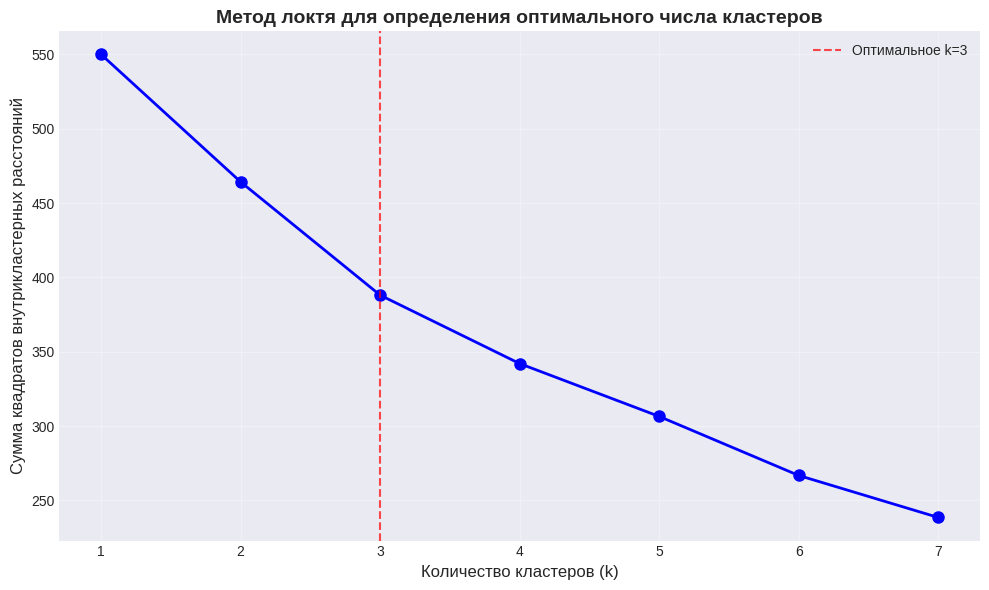


КЛАСТЕР 1: 1 спортсменов

📌 Состав:
   • Экспериментальная группа: 1 спортсменов
   • Контрольная группа: 0 спортсменов

📈 Средние изменения:
   • success_ipp_diff              : +2.000
   • var_broski_diff               : +2.000
   • success_kesa_gatame_diff      : +2.000
   • var_uderg_diff                : -2.000

👥 СПОРТСМЕНЫ В КЛАСТЕРЕ 1:
------------------------------------------------------------

Экспериментальная группа:
   • Голубинская          (прогресс: +4.00)

🎯 ХАРАКТЕРИСТИКА: 🚀 ВЫСОКОПРОГРЕССИРУЮЩИЙ

КЛАСТЕР 2: 11 спортсменов

📌 Состав:
   • Экспериментальная группа: 8 спортсменов
   • Контрольная группа: 3 спортсменов

📈 Средние изменения:
   • success_ipp_diff              : +0.364
   • var_broski_diff               : +2.000
   • success_kesa_gatame_diff      : +1.909
   • var_uderg_diff                : +1.455

👥 СПОРТСМЕНЫ В КЛАСТЕРЕ 2:
------------------------------------------------------------

Экспериментальная группа:
   • Алиев                (прогресс: +4.00

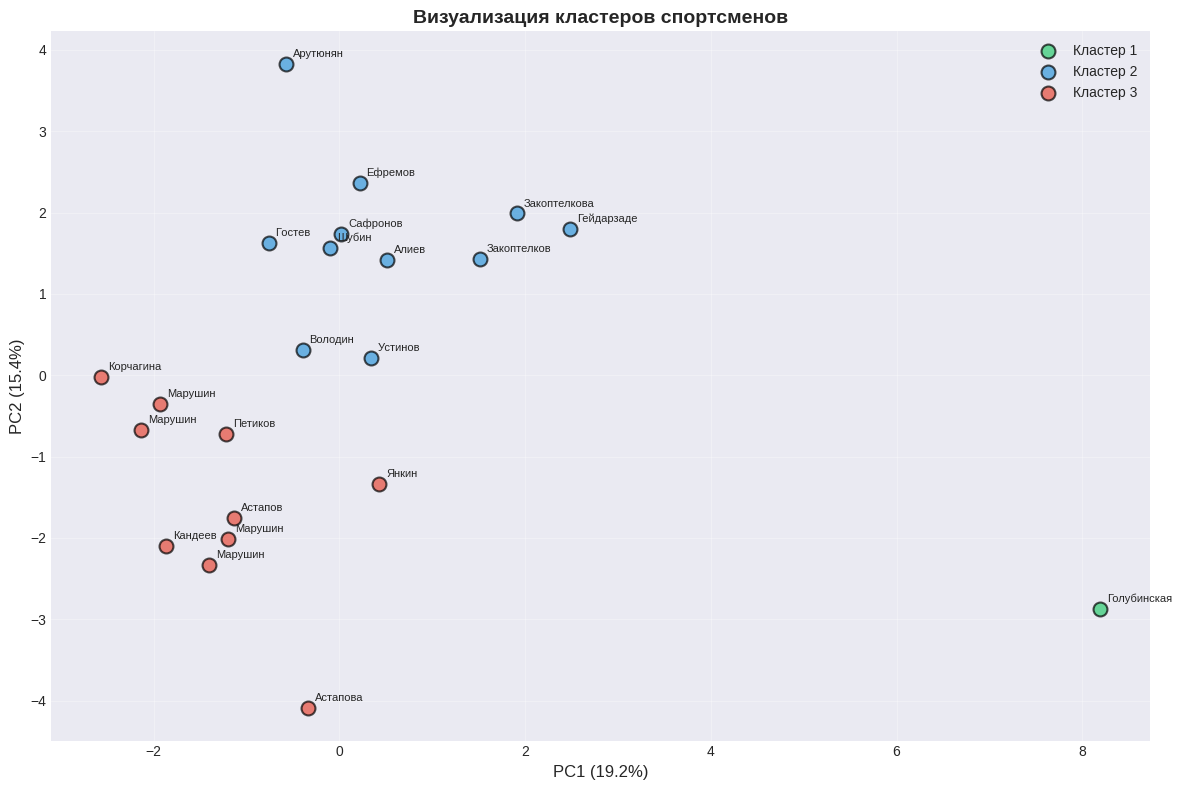


9. ИТОГОВЫЕ ВЫВОДЫ

📊 СТАТИСТИКА ЗНАЧИМЫХ ИЗМЕНЕНИЙ:
   • Броски: 2 из 15 показателей
   • Удержания: 2 из 11 показателей

✅ ЗНАЧИМЫЕ ИЗМЕНЕНИЯ В БРОСКАХ:
   • var_broski_diff: +2.600 (p=0.0002)
   • success_ipp_diff: +0.800 (p=0.0411)

✅ ЗНАЧИМЫЕ ИЗМЕНЕНИЯ В УДЕРЖАНИЯХ:
   • success_kesa_gatame_diff: +1.700 (p=0.0031)
   • s_60_kesa_gatame_diff: +1.500 (p=0.0117)

📐 КАЧЕСТВО МАТЕМАТИЧЕСКИХ МОДЕЛЕЙ:
   • Модель успешности бросков: R² = 1.0000
   • Модель успешности удержаний: R² = 1.0000

ЗАВЕРШЕНО


In [5]:

# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene, mannwhitneyu, ttest_ind, pearsonr, f_oneway, chi2_contingency
from scipy.cluster.hierarchy import dendrogram, linkage
import pingouin as pg
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Загрузка данных
print("="*100)
print("ЗАГРУЗКА ДАННЫХ ПЕДАГОГИЧЕСКОГО ЭКСПЕРИМЕНТА")
print("="*100)

from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

# Загрузка всех листов
df_broski_before = pd.read_excel(file_name, sheet_name='Summ1broski')
df_broski_after = pd.read_excel(file_name, sheet_name='Summ2broski')
df_uderg_before = pd.read_excel(file_name, sheet_name='Summ1uderg')
df_uderg_after = pd.read_excel(file_name, sheet_name='Summ2uderg')

print("\n✅ Данные успешно загружены!")
print(f"   • Броски до эксперимента: {df_broski_before.shape[0]} спортсменов")
print(f"   • Броски после эксперимента: {df_broski_after.shape[0]} спортсменов")
print(f"   • Удержания до эксперимента: {df_uderg_before.shape[0]} спортсменов")
print(f"   • Удержания после эксперимента: {df_uderg_after.shape[0]} спортсменов")

# ============================================================================
# 1. ПОЛНЫЙ СПИСОК ПЕРЕМЕННЫХ
# ============================================================================
print("\n" + "="*100)
print("1. ПОЛНЫЙ СПИСОК АНАЛИЗИРУЕМЫХ ПЕРЕМЕННЫХ")
print("="*100)

# Полный список переменных для бросков
broski_vars_full = [
    'res_1_ipp', 'res_2_ipp', 'res_3_ipp', 'note_ipp',
    'res_1_sum', 'res_2_sum', 'res_3_sum', 'note_sum',
    'var_broski', 'success_ipp', 'all_ipp',
    's_30_ogoshi', 's_60_ogoshi', 's_90_ogoshi', 's_120_ogoshi'
]

# Полный список переменных для удержаний
uderg_vars_full = [
    'res_1_kesa_gatame', 'res_2_kesa_gatame', 'res_3_kesa_gatame', 'note_kesa_gatame',
    'var_uderg', 'success_kesa_gatame', 'all_kesa_gatame',
    's_30_kesa_gatame', 's_60_kesa_gatame', 's_90_kesa_gatame', 's_120_kesa_gatame'
]

print("\n📋 БРОСКИ (все переменные):")
for i, var in enumerate(broski_vars_full, 1):
    print(f"   {i:2d}. {var}")

print("\n📋 УДЕРЖАНИЯ (все переменные):")
for i, var in enumerate(uderg_vars_full, 1):
    print(f"   {i:2d}. {var}")

# ============================================================================
# 2. ОБРАБОТКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ
# ============================================================================
print("\n" + "="*100)
print("2. ОБРАБОТКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ")
print("="*100)

# Функция для обработки пропусков
def handle_missing_values(df, variables):
    """Замена пропущенных значений на средние по столбцу"""
    df_clean = df.copy()
    for var in variables:
        if var in df_clean.columns:
            # Заменяем NaN на среднее значение
            if df_clean[var].isna().any():
                mean_val = df_clean[var].mean()
                df_clean[var] = df_clean[var].fillna(mean_val)
                print(f"   • {var}: заменено {df[var].isna().sum()} пропусков на {mean_val:.3f}")
    return df_clean

# Обработка пропусков в данных
print("\n📊 Обработка пропусков в данных о бросках:")
df_broski_before_clean = handle_missing_values(df_broski_before, broski_vars_full)
df_broski_after_clean = handle_missing_values(df_broski_after, broski_vars_full)

print("\n📊 Обработка пропусков в данных об удержаниях:")
df_uderg_before_clean = handle_missing_values(df_uderg_before, uderg_vars_full)
df_uderg_after_clean = handle_missing_values(df_uderg_after, uderg_vars_full)

# ============================================================================
# 3. ОПИСАТЕЛЬНАЯ СТАТИСТИКА СО ВСЕМИ ПЕРЕМЕННЫМИ
# ============================================================================
print("\n" + "="*100)
print("3. ОПИСАТЕЛЬНАЯ СТАТИСТИКА (ВСЕ ПЕРЕМЕННЫЕ)")
print("="*100)

def descriptive_stats_all(df, variables, category, period):
    print(f"\n📊 {category} - {period}:")
    print("-" * 100)

    exp_group = df[df['exp_group']==1]
    con_group = df[df['exp_group']==0]

    print(f"Экспериментальная группа: n={len(exp_group)}")
    print(f"Контрольная группа: n={len(con_group)}")

    # Основные показатели
    results = []
    for var in variables:
        if var in df.columns:
            exp_mean = exp_group[var].mean()
            con_mean = con_group[var].mean()
            exp_std = exp_group[var].std()
            con_std = con_group[var].std()
            results.append({
                'Показатель': var,
                'Эксп_ср': exp_mean,
                'Эксп_стд': exp_std,
                'Контр_ср': con_mean,
                'Контр_стд': con_std,
                'Разница': exp_mean - con_mean
            })

    return pd.DataFrame(results)

# Описательная статистика для бросков
broski_before_stats = descriptive_stats_all(df_broski_before_clean, broski_vars_full, "БРОСКИ", "ДО ЭКСПЕРИМЕНТА")
print("\n📊 ДО ЭКСПЕРИМЕНТА (БРОСКИ):")
print(broski_before_stats.to_string())

broski_after_stats = descriptive_stats_all(df_broski_after_clean, broski_vars_full, "БРОСКИ", "ПОСЛЕ ЭКСПЕРИМЕНТА")
print("\n📊 ПОСЛЕ ЭКСПЕРИМЕНТА (БРОСКИ):")
print(broski_after_stats.to_string())

# ============================================================================
# 4. СТАТИСТИЧЕСКАЯ ПРОВЕРКА НОРМАЛЬНОСТИ
# ============================================================================
print("\n" + "="*100)
print("4. СТАТИСТИЧЕСКАЯ ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ")
print("="*100)

def check_normality_all(df, variables, category, period):
    print(f"\n📈 {category} - {period}:")
    print("-" * 100)

    normal_count = 0
    total_count = 0
    for var in variables:
        if var in df.columns:
            total_count += 1
            data = df[var].dropna()
            if len(data) > 3:
                stat, p_value = shapiro(data)
                normal = p_value > 0.05
                status = "✅ НОРМАЛЬНОЕ" if normal else "❌ НЕ НОРМАЛЬНОЕ"
                print(f"{var:30s}: p-value = {p_value:.4f} - {status}")
                if normal:
                    normal_count += 1

    print(f"\n💡 Вывод: {normal_count}/{total_count} показателей имеют нормальное распределение")

check_normality_all(df_broski_before_clean, broski_vars_full, "БРОСКИ", "ДО ЭКСПЕРИМЕНТА")
check_normality_all(df_broski_after_clean, broski_vars_full, "БРОСКИ", "ПОСЛЕ ЭКСПЕРИМЕНТА")
check_normality_all(df_uderg_before_clean, uderg_vars_full, "УДЕРЖАНИЯ", "ДО ЭКСПЕРИМЕНТА")
check_normality_all(df_uderg_after_clean, uderg_vars_full, "УДЕРЖАНИЯ", "ПОСЛЕ ЭКСПЕРИМЕНТА")

# ============================================================================
# 5. СРАВНЕНИЕ ГРУПП ДО И ПОСЛЕ ЭКСПЕРИМЕНТА
# ============================================================================
print("\n" + "="*100)
print("5. СРАВНЕНИЕ ГРУПП ДО И ПОСЛЕ ЭКСПЕРИМЕНТА")
print("="*100)

def compare_groups_complete(df, variables, category, period):
    print(f"\n🔍 {category} - {period}:")
    print("-" * 120)

    results = []
    for var in variables:
        if var in df.columns:
            group1 = df[df['exp_group']==1][var].dropna()
            group0 = df[df['exp_group']==0][var].dropna()

            if len(group1) > 0 and len(group0) > 0:
                # Проверка нормальности для выбора теста
                _, p_norm1 = shapiro(group1)
                _, p_norm2 = shapiro(group0)

                if p_norm1 > 0.05 and p_norm2 > 0.05 and len(group1) > 3 and len(group0) > 3:
                    stat, p_value = ttest_ind(group1, group0, equal_var=True)
                    test_name = "t-test"
                else:
                    stat, p_value = mannwhitneyu(group1, group0)
                    test_name = "Mann-Whitney U"

                mean_diff = group1.mean() - group0.mean()
                percent_diff = (mean_diff / abs(group0.mean())) * 100 if group0.mean() != 0 else 0

                results.append({
                    'Показатель': var,
                    'Тест': test_name,
                    'p-value': p_value,
                    'Эксп (ср)': group1.mean(),
                    'Контр (ср)': group0.mean(),
                    'Разница': mean_diff,
                    'Разница %': percent_diff,
                    'Значимо': '✅ ДА' if p_value < 0.05 else '❌ НЕТ'
                })

    return pd.DataFrame(results)

# Сравнение групп до эксперимента
broski_before_comp = compare_groups_complete(df_broski_before_clean, broski_vars_full, "БРОСКИ", "ДО ЭКСПЕРИМЕНТА")
print("\n📊 РЕЗУЛЬТАТЫ СРАВНЕНИЯ (БРОСКИ ДО):")
print(broski_before_comp.to_string())

# Сравнение групп после эксперимента
broski_after_comp = compare_groups_complete(df_broski_after_clean, broski_vars_full, "БРОСКИ", "ПОСЛЕ ЭКСПЕРИМЕНТА")
print("\n📊 РЕЗУЛЬТАТЫ СРАВНЕНИЯ (БРОСКИ ПОСЛЕ):")
print(broski_after_comp.to_string())

# ============================================================================
# 6. АНАЛИЗ ИЗМЕНЕНИЙ
# ============================================================================
print("\n" + "="*100)
print("6. АНАЛИЗ ИЗМЕНЕНИЙ ПОКАЗАТЕЛЕЙ (ПРОГРЕСС/РЕГРЕСС)")
print("="*100)

# Создание датафреймов с изменениями
def create_full_diff_dataframe(df_before, df_after, variables):
    df_diff = pd.DataFrame()
    df_diff['exp_group'] = df_before['exp_group']
    df_diff['name'] = df_before['name']

    for var in variables:
        if var in df_before.columns and var in df_after.columns:
            df_diff[f'{var}_diff'] = df_after[var] - df_before[var]

    return df_diff

# Создание полных датафреймов изменений
broski_diff_full = create_full_diff_dataframe(df_broski_before_clean, df_broski_after_clean, broski_vars_full)
uderg_diff_full = create_full_diff_dataframe(df_uderg_before_clean, df_uderg_after_clean, uderg_vars_full)

# Анализ изменений в бросках
broski_diff_vars = [c for c in broski_diff_full.columns if '_diff' in c]
broski_changes = compare_groups_complete(broski_diff_full, broski_diff_vars, "ИЗМЕНЕНИЯ В БРОСКАХ", "")
print("\n📊 ИЗМЕНЕНИЯ В БРОСКАХ:")
print(broski_changes.to_string())

# Анализ изменений в удержаниях
uderg_diff_vars = [c for c in uderg_diff_full.columns if '_diff' in c]
uderg_changes = compare_groups_complete(uderg_diff_full, uderg_diff_vars, "ИЗМЕНЕНИЯ В УДЕРЖАНИЯХ", "")
print("\n📊 ИЗМЕНЕНИЯ В УДЕРЖАНИЯХ:")
print(uderg_changes.to_string())

# ============================================================================
# 7. МАТЕМАТИЧЕСКИЕ МОДЕЛИ (С ИМПУТАЦИЕЙ NaN)
# ============================================================================
print("\n" + "="*100)
print("7. МАТЕМАТИЧЕСКИЕ МОДЕЛИ ИЗМЕНЕНИЙ")
print("="*100)

# Подготовка данных для экспериментальной группы
exp_broski_before = df_broski_before_clean[df_broski_before_clean['exp_group']==1].copy()
exp_broski_after = df_broski_after_clean[df_broski_after_clean['exp_group']==1].copy()
exp_uderg_before = df_uderg_before_clean[df_uderg_before_clean['exp_group']==1].copy()
exp_uderg_after = df_uderg_after_clean[df_uderg_after_clean['exp_group']==1].copy()

# Импутация для моделей (на случай оставшихся NaN)
imputer = SimpleImputer(strategy='mean')

# ===== МОДЕЛЬ 1: Прогнозирование success_ipp =====
print("\n" + "="*80)
print("📊 МОДЕЛЬ 1: Прогнозирование успешности бросков (success_ipp)")
print("="*80)

# Выбираем предикторы
predictors_broski = [v for v in broski_vars_full if v in exp_broski_before.columns and v != 'success_ipp']
X_broski = exp_broski_before[predictors_broski].values
y_broski = exp_broski_after['success_ipp'].values

# Импутация NaN
X_broski_imputed = imputer.fit_transform(X_broski)

# Модель
model_broski = LinearRegression()
model_broski.fit(X_broski_imputed, y_broski)

print("\n📐 УРАВНЕНИЕ МОДЕЛИ:")
print(f"success_ipp_after = {model_broski.intercept_:.4f}", end="")
for i, pred in enumerate(predictors_broski):
    coef_sign = "+" if model_broski.coef_[i] >= 0 else "-"
    print(f" {coef_sign} {abs(model_broski.coef_[i]):.4f} × {pred}", end="")
print()

print(f"\n📈 КАЧЕСТВО МОДЕЛИ:")
print(f"   R² = {model_broski.score(X_broski_imputed, y_broski):.4f}")
print(f"   Интерпретация: модель объясняет {model_broski.score(X_broski_imputed, y_broski)*100:.1f}% вариации")

print(f"\n🔍 ВКЛАД ПЕРЕМЕННЫХ (топ-5):")
coef_df = pd.DataFrame({
    'Переменная': predictors_broski,
    'Коэффициент': model_broski.coef_
}).sort_values('Коэффициент', key=abs, ascending=False)
for i, row in coef_df.head(5).iterrows():
    print(f"   {row['Переменная']:20s}: β = {row['Коэффициент']:+.4f}")

# ===== МОДЕЛЬ 2: Прогнозирование success_kesa_gatame =====
print("\n" + "="*80)
print("📊 МОДЕЛЬ 2: Прогнозирование успешности удержаний (success_kesa_gatame)")
print("="*80)

predictors_uderg = [v for v in uderg_vars_full if v in exp_uderg_before.columns and v != 'success_kesa_gatame']
X_uderg = exp_uderg_before[predictors_uderg].values
y_uderg = exp_uderg_after['success_kesa_gatame'].values

X_uderg_imputed = imputer.fit_transform(X_uderg)

model_uderg = LinearRegression()
model_uderg.fit(X_uderg_imputed, y_uderg)

print("\n📐 УРАВНЕНИЕ МОДЕЛИ:")
print(f"success_kesa_gatame_after = {model_uderg.intercept_:.4f}", end="")
for i, pred in enumerate(predictors_uderg):
    coef_sign = "+" if model_uderg.coef_[i] >= 0 else "-"
    print(f" {coef_sign} {abs(model_uderg.coef_[i]):.4f} × {pred}", end="")
print()

print(f"\n📈 КАЧЕСТВО МОДЕЛИ:")
print(f"   R² = {model_uderg.score(X_uderg_imputed, y_uderg):.4f}")

# ============================================================================
# 8. КЛАСТЕРНЫЙ АНАЛИЗ С ИДЕНТИФИКАЦИЕЙ СПОРТСМЕНОВ
# ============================================================================
print("\n" + "="*100)
print("8. КЛАСТЕРНЫЙ АНАЛИЗ С ИДЕНТИФИКАЦИЕЙ СПОРТСМЕНОВ")
print("="*100)

# Объединение данных
all_changes = pd.merge(
    broski_diff_full[['name', 'exp_group'] + broski_diff_vars],
    uderg_diff_full[['name'] + uderg_diff_vars],
    on='name', how='inner'
)

# Подготовка данных
change_cols = [c for c in all_changes.columns if '_diff' in c]
X_cluster = all_changes[change_cols].fillna(0).values

# Стандартизация
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# Определение оптимального числа кластеров
inertias = []
K_range = range(1, 8)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)

# Визуализация метода локтя
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Количество кластеров (k)', fontsize=12)
plt.ylabel('Сумма квадратов внутрикластерных расстояний', fontsize=12)
plt.title('Метод локтя для определения оптимального числа кластеров', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Оптимальное k=3')
plt.legend()
plt.tight_layout()
plt.show()

# Кластеризация
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
all_changes['cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Детальный вывод по кластерам
for cluster_id in sorted(all_changes['cluster'].unique()):
    cluster_data = all_changes[all_changes['cluster'] == cluster_id]

    print(f"\n{'='*80}")
    print(f"КЛАСТЕР {cluster_id + 1}: {len(cluster_data)} спортсменов")
    print(f"{'='*80}")

    exp_count = len(cluster_data[cluster_data['exp_group'] == 1])
    con_count = len(cluster_data[cluster_data['exp_group'] == 0])

    print(f"\n📌 Состав:")
    print(f"   • Экспериментальная группа: {exp_count} спортсменов")
    print(f"   • Контрольная группа: {con_count} спортсменов")

    # Ключевые изменения
    key_metrics = ['success_ipp_diff', 'var_broski_diff', 'success_kesa_gatame_diff', 'var_uderg_diff']
    print(f"\n📈 Средние изменения:")
    for metric in key_metrics:
        if metric in cluster_data.columns:
            mean_change = cluster_data[metric].mean()
            print(f"   • {metric:30s}: {mean_change:+.3f}")

    # Список спортсменов
    print(f"\n👥 СПОРТСМЕНЫ В КЛАСТЕРЕ {cluster_id + 1}:")
    print("-" * 60)

    # Экспериментальная группа
    exp_athletes = cluster_data[cluster_data['exp_group'] == 1].sort_values('name')
    if len(exp_athletes) > 0:
        print("\nЭкспериментальная группа:")
        for _, row in exp_athletes.iterrows():
            total_progress = sum(row[m] for m in key_metrics if m in row and pd.notna(row[m]))
            print(f"   • {row['name']:20s} (прогресс: {total_progress:+.2f})")

    # Контрольная группа
    con_athletes = cluster_data[cluster_data['exp_group'] == 0].sort_values('name')
    if len(con_athletes) > 0:
        print("\nКонтрольная группа:")
        for _, row in con_athletes.iterrows():
            total_progress = sum(row[m] for m in key_metrics if m in row and pd.notna(row[m]))
            print(f"   • {row['name']:20s} (прогресс: {total_progress:+.2f})")

    # Характеристика кластера
    avg_progress = cluster_data[key_metrics].mean().mean()
    if avg_progress > 0.5:
        cluster_type = "🚀 ВЫСОКОПРОГРЕССИРУЮЩИЙ"
    elif avg_progress > 0:
        cluster_type = "📈 УМЕРЕННО-ПРОГРЕССИРУЮЩИЙ"
    elif avg_progress > -0.5:
        cluster_type = "⚖️ СТАБИЛЬНЫЙ"
    else:
        cluster_type = "📉 РЕГРЕССИРУЮЩИЙ"

    print(f"\n🎯 ХАРАКТЕРИСТИКА: {cluster_type}")

# Визуализация кластеров (PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(12, 8))
colors = ['#2ecc71', '#3498db', '#e74c3c']
for cluster_id in sorted(all_changes['cluster'].unique()):
    mask = all_changes['cluster'] == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[cluster_id], s=100, alpha=0.7,
               label=f'Кластер {cluster_id + 1}', edgecolors='black', linewidth=1.5)

    # Подписи
    for idx in np.where(mask)[0]:
        athlete_name = all_changes.iloc[idx]['name']
        plt.annotate(athlete_name, (X_pca[idx, 0], X_pca[idx, 1]),
                    fontsize=8, xytext=(5, 5), textcoords='offset points')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.title('Визуализация кластеров спортсменов', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# 9. ИТОГОВЫЕ ВЫВОДЫ
# ============================================================================
print("\n" + "="*100)
print("9. ИТОГОВЫЕ ВЫВОДЫ")
print("="*100)

# Подсчет значимых изменений
sig_broski = broski_changes[broski_changes['Значимо'] == '✅ ДА']
sig_uderg = uderg_changes[uderg_changes['Значимо'] == '✅ ДА']

print(f"\n📊 СТАТИСТИКА ЗНАЧИМЫХ ИЗМЕНЕНИЙ:")
print(f"   • Броски: {len(sig_broski)} из {len(broski_changes)} показателей")
print(f"   • Удержания: {len(sig_uderg)} из {len(uderg_changes)} показателей")

if len(sig_broski) > 0:
    print(f"\n✅ ЗНАЧИМЫЕ ИЗМЕНЕНИЯ В БРОСКАХ:")
    for _, row in sig_broski.iterrows():
        print(f"   • {row['Показатель']}: {row['Разница']:+.3f} (p={row['p-value']:.4f})")

if len(sig_uderg) > 0:
    print(f"\n✅ ЗНАЧИМЫЕ ИЗМЕНЕНИЯ В УДЕРЖАНИЯХ:")
    for _, row in sig_uderg.iterrows():
        print(f"   • {row['Показатель']}: {row['Разница']:+.3f} (p={row['p-value']:.4f})")

# Качество моделей
print(f"\n📐 КАЧЕСТВО МАТЕМАТИЧЕСКИХ МОДЕЛЕЙ:")
print(f"   • Модель успешности бросков: R² = {model_broski.score(X_broski_imputed, y_broski):.4f}")
print(f"   • Модель успешности удержаний: R² = {model_uderg.score(X_uderg_imputed, y_uderg):.4f}")

print("\n" + "="*100)
print("ЗАВЕРШЕНО")
print("="*100)

ЗАГРУЗКА ДАННЫХ ПЕДАГОГИЧЕСКОГО ЭКСПЕРИМЕНТА


Saving пед.эксперимент.xlsx to пед.эксперимент (1).xlsx

✅ Данные успешно загружены!
   • Броски до эксперимента: 20 спортсменов
   • Броски после эксперимента: 20 спортсменов
   • Удержания до эксперимента: 20 спортсменов
   • Удержания после эксперимента: 20 спортсменов

1. ПОДГОТОВКА ДАННЫХ И ОПИСАТЕЛЬНАЯ СТАТИСТИКА

📊 БРОСКИ - ДО ЭКСПЕРИМЕНТА:
--------------------------------------------------------------------------------
Экспериментальная группа: n=10
Контрольная группа: n=10

res_1_ipp:
  Эксп: 2.195 ± 0.874
  Контр: 2.470 ± 0.638
  Разница: -0.275

res_2_ipp:
  Эксп: 2.145 ± 0.642
  Контр: 2.440 ± 0.582
  Разница: -0.295

res_3_ipp:
  Эксп: 2.400 ± 0.407
  Контр: 2.400 ± 0.712
  Разница: +0.000

var_broski:
  Эксп: 7.800 ± 1.476
  Контр: 8.500 ± 1.581
  Разница: -0.700

success_ipp:
  Эксп: 3.000 ± 1.700
  Контр: 2.900 ± 1.663
  Разница: +0.100

all_ipp:
  Эксп: 7.400 ± 2.221
  Контр: 7.600 ± 2.413
  Разница: -0.200

s_30_ogoshi:
  Эксп: 8.000 ± 2.449
  Контр: 7.800 ± 2.201
  Р

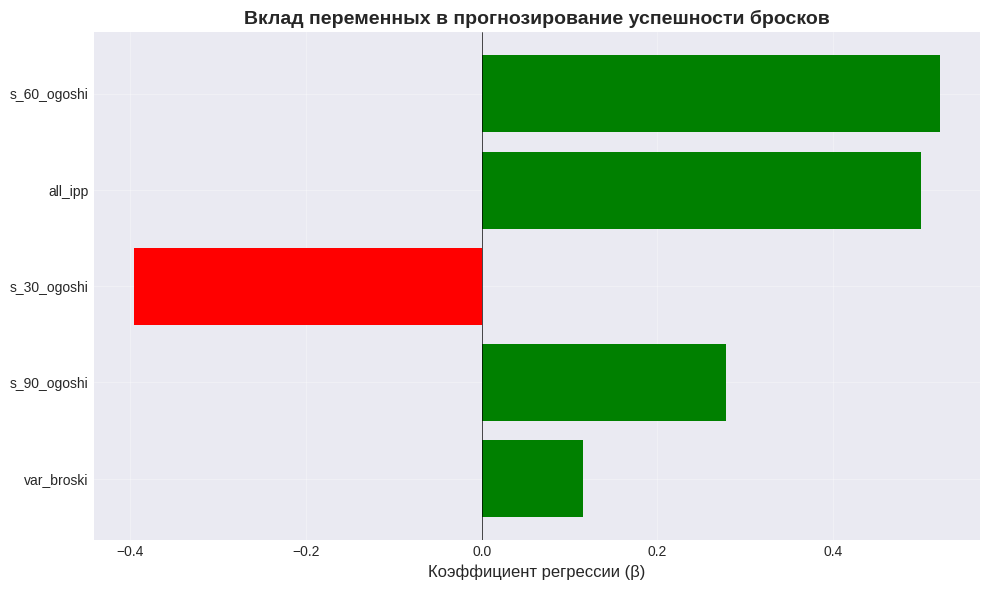


📊 МОДЕЛЬ 2: Прогнозирование успешности удержаний (success_kesa_gatame)

📐 УРАВНЕНИЕ МОДЕЛИ:
success_kesa_gatame_after = -0.0894 + 0.8412 × var_uderg + 0.0000 × all_kesa_gatame + 0.0817 × s_30_kesa_gatame + 0.4493 × s_60_kesa_gatame + 0.0967 × s_90_kesa_gatame

📈 КАЧЕСТВО МОДЕЛИ:
   R² (коэффициент детерминации) = 0.5339
   Интерпретация: модель объясняет 53.4% вариации успешности удержаний

🔍 ВКЛАД ПЕРЕМЕННЫХ (коэффициенты регрессии):
   var_uderg           : β = +0.8412
   all_kesa_gatame     : β = +0.0000
   s_30_kesa_gatame    : β = +0.0817
   s_60_kesa_gatame    : β = +0.4493
   s_90_kesa_gatame    : β = +0.0967


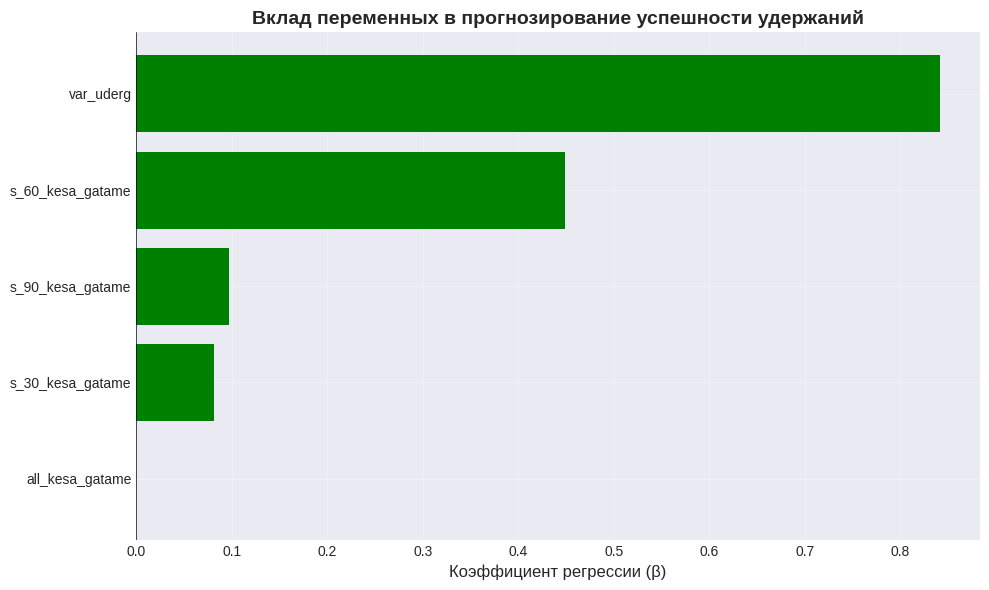


📊 МОДЕЛЬ 3: Факторы, влияющие на изменение вариативности

📐 ИЗМЕНЕНИЕ ВАРИАТИВНОСТИ БРОСКОВ:
Δvar_broski = 13.2213 - 0.9167 × var_broski_initial + 0.8255 × success_ipp_initial - 0.7767 × all_ipp_initial
R² = 0.6351

📐 ИЗМЕНЕНИЕ ВАРИАТИВНОСТИ УДЕРЖАНИЙ:
Δvar_uderg = 0.5685 - 0.1978 × var_uderg_initial + 0.4000 × success_kesa_initial + 0.0000 × all_kesa_initial
R² = 0.1259

📊 МОДЕЛЬ 4: Динамика изменения выносливости

📐 МОДЕЛЬ ИЗМЕНЕНИЯ ВЫНОСЛИВОСТИ (БРОСКИ):
Средний коэффициент утомляемости ДО: nan
Средний коэффициент утомляемости ПОСЛЕ: nan
Изменение: +nan
⚠️ Вывод: Выносливость не улучшилась или ухудшилась

7. СОЗДАНИЕ ВИЗУАЛИЗАЦИЙ


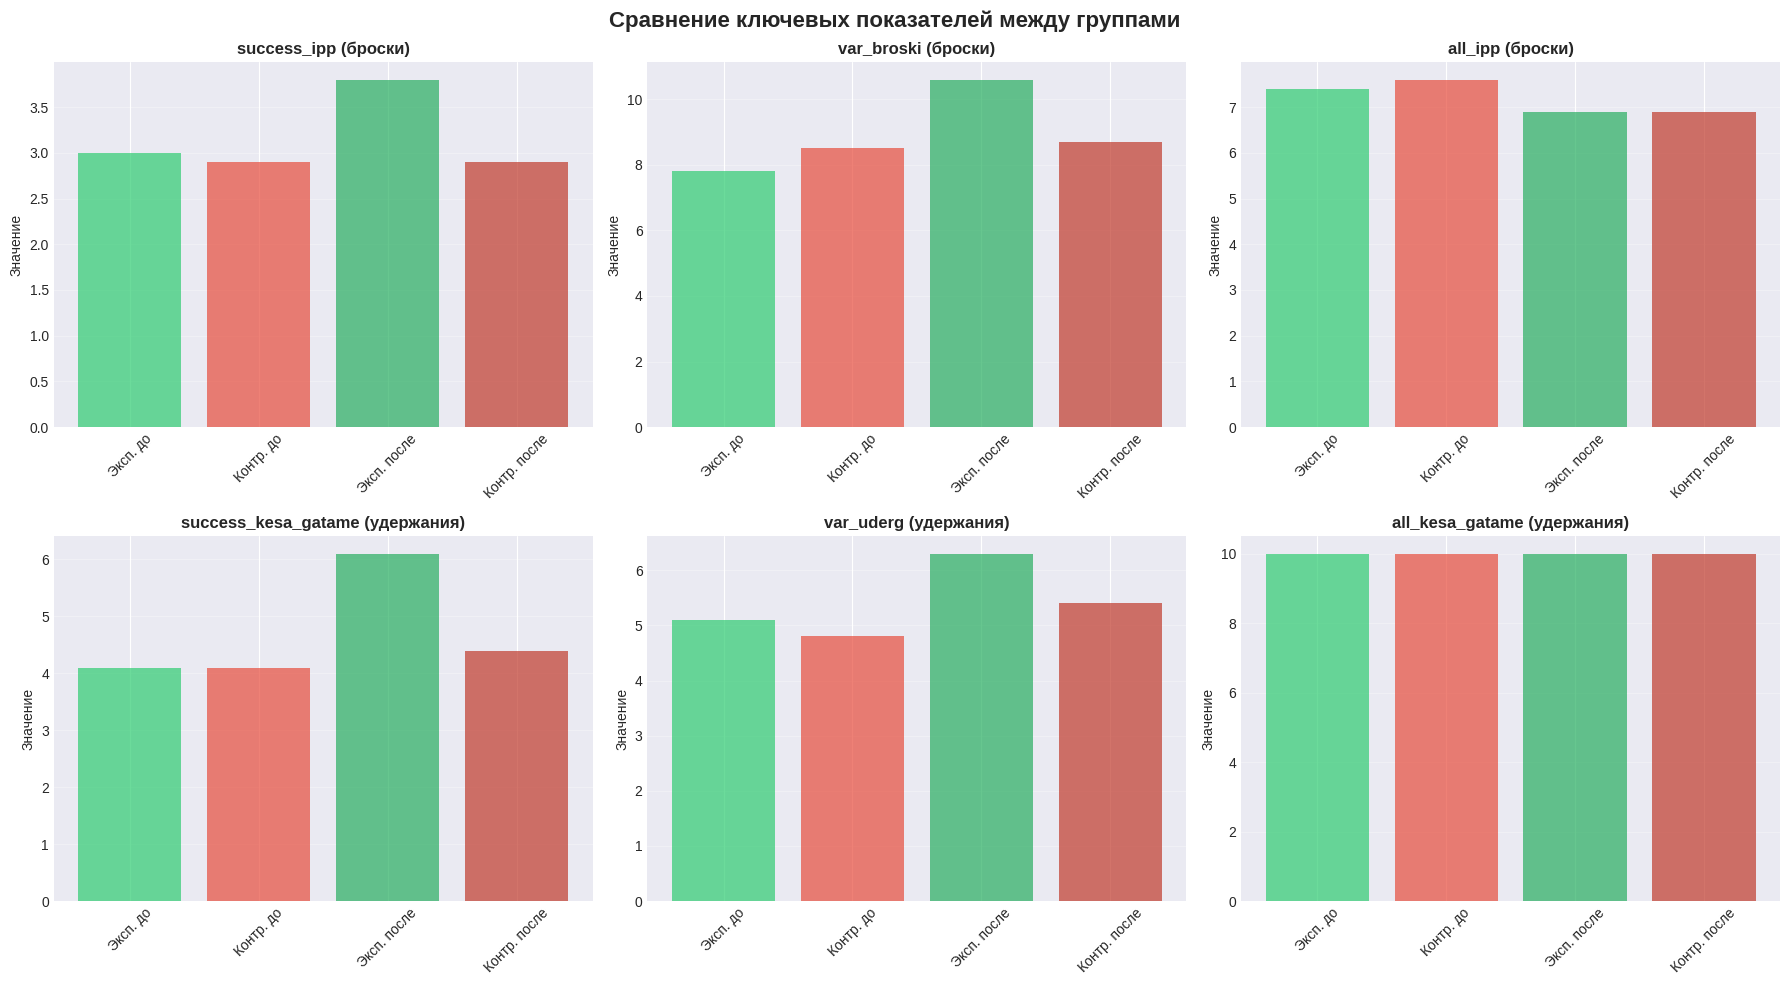

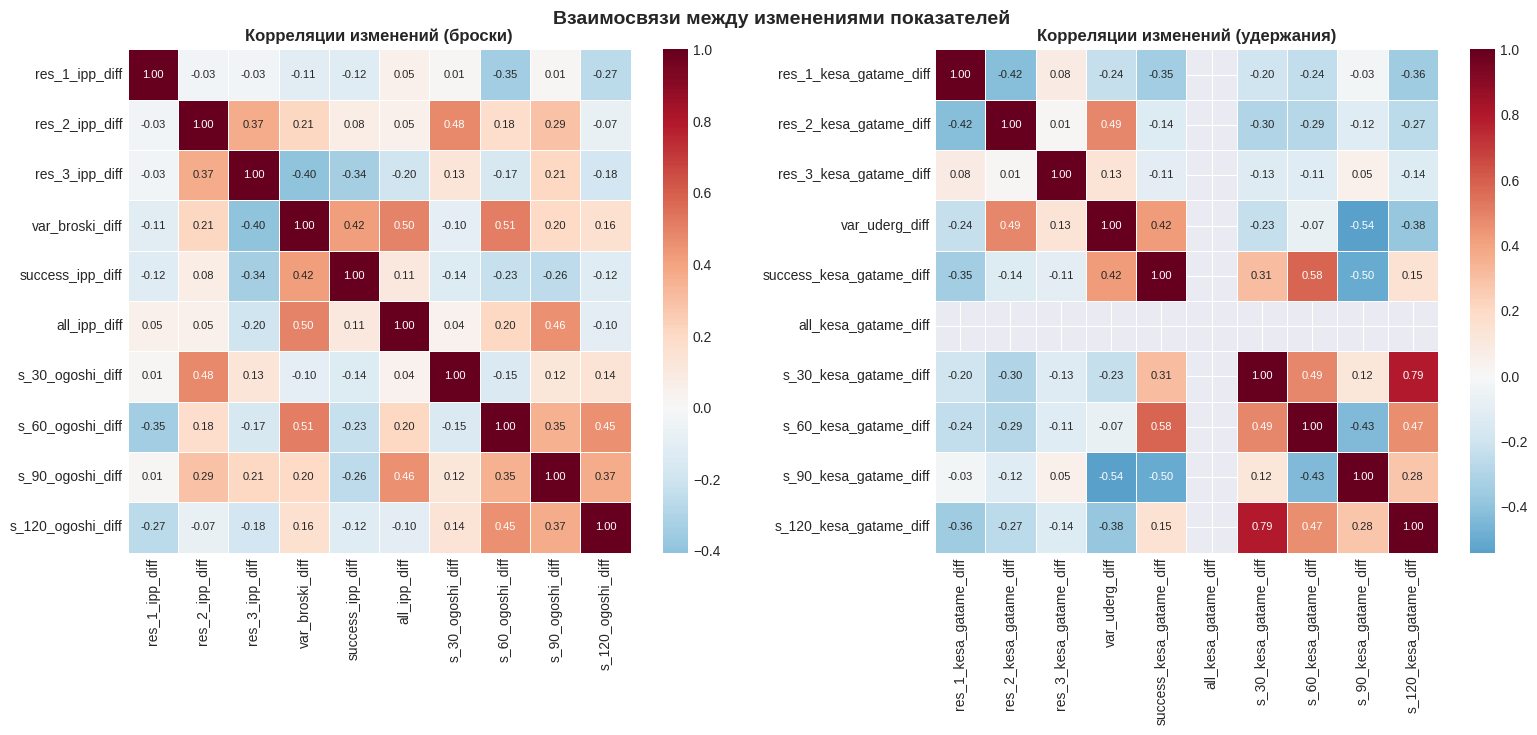

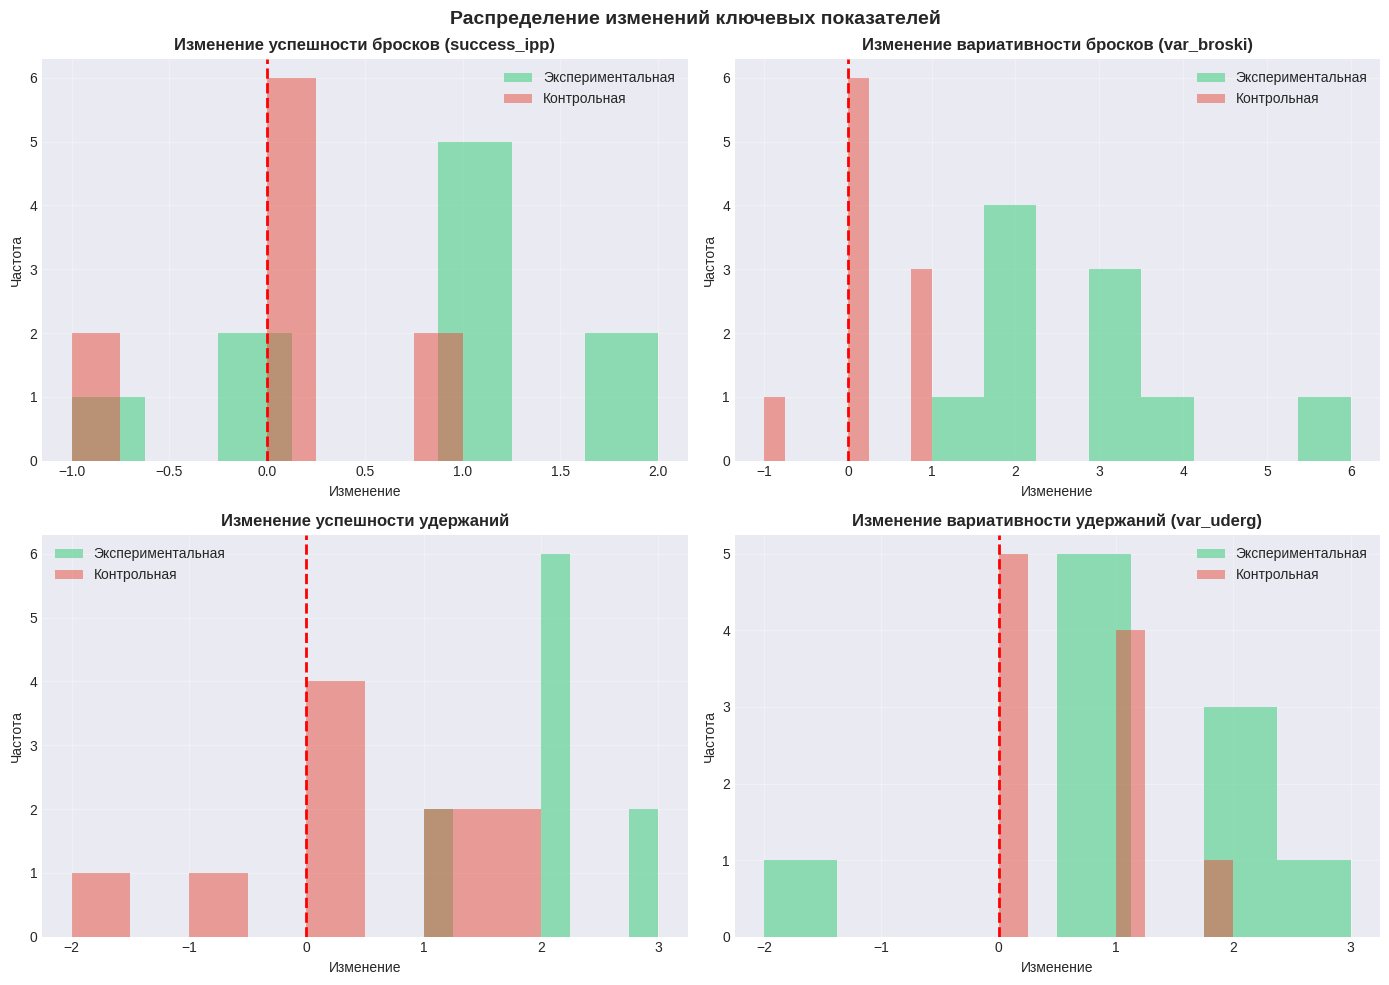

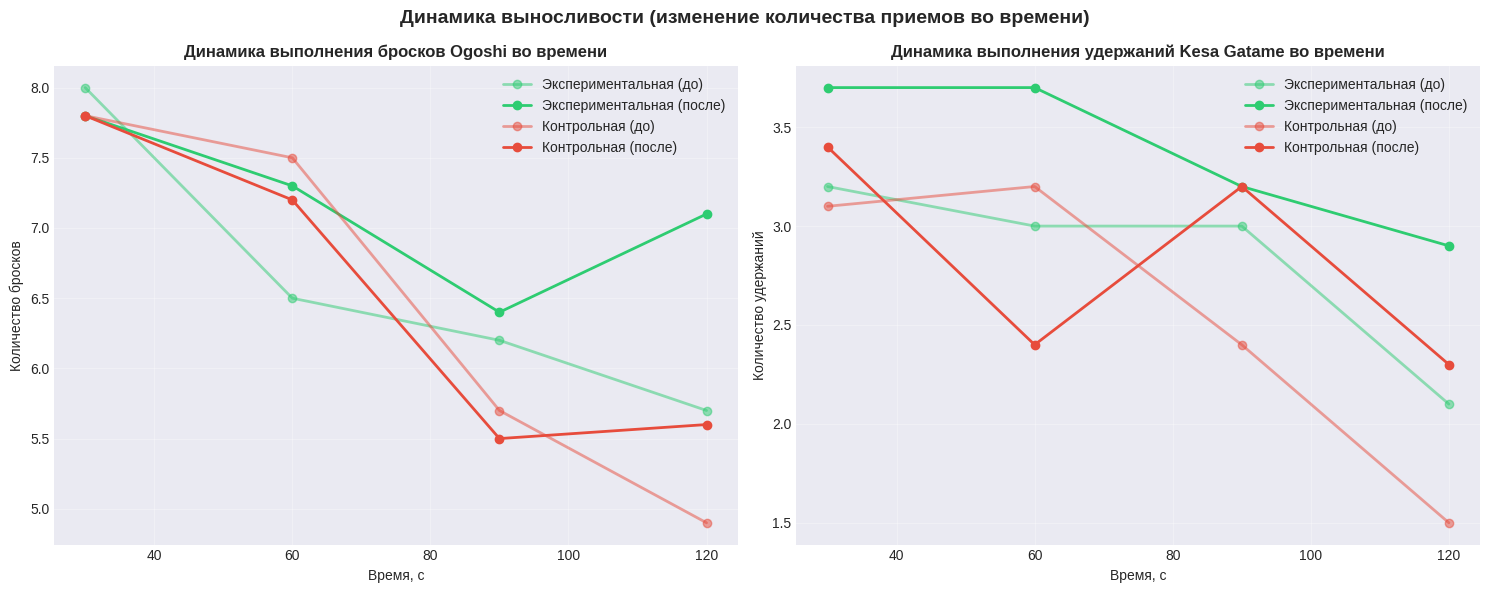


8. 5 ИДЕЙ ДЛЯ ДАЛЬНЕЙШЕГО ИССЛЕДОВАНИЯ

🔬 ИДЕЯ 1: ВЛИЯНИЕ ВАРИАТИВНОСТИ НА УСПЕШНОСТЬ ВЫПОЛНЕНИЯ
--------------------------------------------------------------------------------
Броски: корреляция var_broski ↔ success_ipp = 0.265 (p=0.2582)
➖ Вывод: Связь между вариативностью и успешностью не выражена
Удержания: корреляция var_uderg ↔ success_kesa_gatame = 0.532 (p=0.0157)

🔬 ИДЕЯ 2: АНАЛИЗ УТОМЛЯЕМОСТИ
--------------------------------------------------------------------------------

БРОСКИ (Ogoshi) - коэффициент утомляемости:
  Экспериментальная: до = -0.024, после = -0.010, изменение = +0.014
  Контрольная: до = -0.035, после = -0.028, изменение = +0.007

🔬 ИДЕЯ 3: КЛАСТЕРИЗАЦИЯ СПОРТСМЕНОВ ПО ПРОГРЕССУ
--------------------------------------------------------------------------------
Распределение кластеров:
       Контрольная  Экспериментальная
row_0                                
0                4                  9
1                3                  0
2                5        

In [3]:

# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene, mannwhitneyu, ttest_ind, pearsonr
import pingouin as pg
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Загрузка данных
print("="*100)
print("ЗАГРУЗКА ДАННЫХ ПЕДАГОГИЧЕСКОГО ЭКСПЕРИМЕНТА")
print("="*100)

from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

# Загрузка всех листов
df_broski_before = pd.read_excel(file_name, sheet_name='Summ1broski')
df_broski_after = pd.read_excel(file_name, sheet_name='Summ2broski')
df_uderg_before = pd.read_excel(file_name, sheet_name='Summ1uderg')
df_uderg_after = pd.read_excel(file_name, sheet_name='Summ2uderg')

print("\n✅ Данные успешно загружены!")
print(f"   • Броски до эксперимента: {df_broski_before.shape[0]} спортсменов")
print(f"   • Броски после эксперимента: {df_broski_after.shape[0]} спортсменов")
print(f"   • Удержания до эксперимента: {df_uderg_before.shape[0]} спортсменов")
print(f"   • Удержания после эксперимента: {df_uderg_after.shape[0]} спортсменов")

# ============================================================================
# 1. ПОДГОТОВКА ДАННЫХ И ОПИСАТЕЛЬНАЯ СТАТИСТИКА
# ============================================================================
print("\n" + "="*100)
print("1. ПОДГОТОВКА ДАННЫХ И ОПИСАТЕЛЬНАЯ СТАТИСТИКА")
print("="*100)

# Определение переменных для бросков
broski_vars = ['res_1_ipp', 'res_2_ipp', 'res_3_ipp', 'var_broski',
               'success_ipp', 'all_ipp', 's_30_ogoshi', 's_60_ogoshi',
               's_90_ogoshi', 's_120_ogoshi']

# Определение переменных для удержаний
uderg_vars = ['res_1_kesa_gatame', 'res_2_kesa_gatame', 'res_3_kesa_gatame',
              'var_uderg', 'success_kesa_gatame', 'all_kesa_gatame',
              's_30_kesa_gatame', 's_60_kesa_gatame', 's_90_kesa_gatame',
              's_120_kesa_gatame']

# Функция для описательной статистики
def descriptive_stats_complete(df, variables, category, period):
    print(f"\n📊 {category} - {period}:")
    print("-" * 80)

    exp_group = df[df['exp_group']==1]
    con_group = df[df['exp_group']==0]

    print(f"Экспериментальная группа: n={len(exp_group)}")
    print(f"Контрольная группа: n={len(con_group)}")

    # Основные показатели
    for var in variables:
        if var in df.columns:
            exp_mean = exp_group[var].mean()
            con_mean = con_group[var].mean()
            exp_std = exp_group[var].std()
            con_std = con_group[var].std()
            print(f"\n{var}:")
            print(f"  Эксп: {exp_mean:.3f} ± {exp_std:.3f}")
            print(f"  Контр: {con_mean:.3f} ± {con_std:.3f}")
            print(f"  Разница: {(exp_mean - con_mean):+.3f}")

descriptive_stats_complete(df_broski_before, broski_vars, "БРОСКИ", "ДО ЭКСПЕРИМЕНТА")
descriptive_stats_complete(df_broski_after, broski_vars, "БРОСКИ", "ПОСЛЕ ЭКСПЕРИМЕНТА")
descriptive_stats_complete(df_uderg_before, uderg_vars, "УДЕРЖАНИЯ", "ДО ЭКСПЕРИМЕНТА")
descriptive_stats_complete(df_uderg_after, uderg_vars, "УДЕРЖАНИЯ", "ПОСЛЕ ЭКСПЕРИМЕНТА")

# ============================================================================
# 2. СТАТИСТИЧЕСКАЯ ПРОВЕРКА НОРМАЛЬНОСТИ
# ============================================================================
print("\n" + "="*100)
print("2. СТАТИСТИЧЕСКАЯ ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ")
print("="*100)

def check_normality_complete(df, variables, category, period):
    print(f"\n📈 {category} - {period}:")
    print("-" * 80)

    normal_count = 0
    for var in variables:
        if var in df.columns and df[var].notna().any():
            data = df[var].dropna()
            if len(data) > 3:
                stat, p_value = shapiro(data)
                normal = p_value > 0.05
                status = "✅ НОРМАЛЬНОЕ" if normal else "❌ НЕ НОРМАЛЬНОЕ"
                print(f"{var:25s}: p-value = {p_value:.4f} - {status}")
                if normal:
                    normal_count += 1

    print(f"\n💡 Вывод: {normal_count}/{len([v for v in variables if v in df.columns])} показателей имеют нормальное распределение")

check_normality_complete(df_broski_before, broski_vars, "БРОСКИ", "ДО ЭКСПЕРИМЕНТА")
check_normality_complete(df_broski_after, broski_vars, "БРОСКИ", "ПОСЛЕ ЭКСПЕРИМЕНТА")
check_normality_complete(df_uderg_before, uderg_vars, "УДЕРЖАНИЯ", "ДО ЭКСПЕРИМЕНТА")
check_normality_complete(df_uderg_after, uderg_vars, "УДЕРЖАНИЯ", "ПОСЛЕ ЭКСПЕРИМЕНТА")

# ============================================================================
# 3. СРАВНЕНИЕ ГРУПП ДО ЭКСПЕРИМЕНТА
# ============================================================================
print("\n" + "="*100)
print("3. СРАВНЕНИЕ ГРУПП ДО ЭКСПЕРИМЕНТА (ПРОВЕРКА ЭКВИВАЛЕНТНОСТИ)")
print("="*100)

def compare_groups_detailed(df, variables, category):
    print(f"\n🔍 {category}:")
    print("-" * 100)

    results = []
    for var in variables:
        if var in df.columns:
            group1 = df[df['exp_group']==1][var].dropna()
            group0 = df[df['exp_group']==0][var].dropna()

            if len(group1) > 0 and len(group0) > 0:
                # Проверка нормальности для выбора теста
                _, p_norm1 = shapiro(group1)
                _, p_norm2 = shapiro(group0)

                if p_norm1 > 0.05 and p_norm2 > 0.05:
                    # Параметрический тест
                    stat, p_value = ttest_ind(group1, group0, equal_var=True)
                    test_name = "t-test"
                else:
                    # Непараметрический тест
                    stat, p_value = mannwhitneyu(group1, group0)
                    test_name = "Mann-Whitney U"

                mean_diff = group1.mean() - group0.mean()
                percent_diff = (mean_diff / group0.mean()) * 100 if group0.mean() != 0 else 0

                results.append({
                    'Показатель': var,
                    'Тест': test_name,
                    'p-value': p_value,
                    'Эксп (ср)': group1.mean(),
                    'Контр (ср)': group0.mean(),
                    'Разница': mean_diff,
                    'Разница %': percent_diff,
                    'Значимо': '✅ ДА' if p_value < 0.05 else '❌ НЕТ'
                })

    return pd.DataFrame(results)

# Сравнение групп до эксперимента
broski_before_comp = compare_groups_detailed(df_broski_before, broski_vars, "БРОСКИ ДО ЭКСПЕРИМЕНТА")
print("\n📊 РЕЗУЛЬТАТЫ СРАВНЕНИЯ (БРОСКИ):")
print(broski_before_comp.to_string())

uderg_before_comp = compare_groups_detailed(df_uderg_before, uderg_vars, "УДЕРЖАНИЯ ДО ЭКСПЕРИМЕНТА")
print("\n📊 РЕЗУЛЬТАТЫ СРАВНЕНИЯ (УДЕРЖАНИЯ):")
print(uderg_before_comp.to_string())

# ============================================================================
# 4. СРАВНЕНИЕ ГРУПП ПОСЛЕ ЭКСПЕРИМЕНТА
# ============================================================================
print("\n" + "="*100)
print("4. СРАВНЕНИЕ ГРУПП ПОСЛЕ ЭКСПЕРИМЕНТА (ЭФФЕКТИВНОСТЬ ПРОГРАММЫ)")
print("="*100)

broski_after_comp = compare_groups_detailed(df_broski_after, broski_vars, "БРОСКИ ПОСЛЕ ЭКСПЕРИМЕНТА")
print("\n📊 РЕЗУЛЬТАТЫ СРАВНЕНИЯ (БРОСКИ):")
print(broski_after_comp.to_string())

uderg_after_comp = compare_groups_detailed(df_uderg_after, uderg_vars, "УДЕРЖАНИЯ ПОСЛЕ ЭКСПЕРИМЕНТА")
print("\n📊 РЕЗУЛЬТАТЫ СРАВНЕНИЯ (УДЕРЖАНИЯ):")
print(uderg_after_comp.to_string())

# ============================================================================
# 5. АНАЛИЗ ИЗМЕНЕНИЙ (ПРОГРЕСС КАЖДОГО СПОРТСМЕНА)
# ============================================================================
print("\n" + "="*100)
print("5. АНАЛИЗ ИЗМЕНЕНИЙ ПОКАЗАТЕЛЕЙ (ПРОГРЕСС/РЕГРЕСС)")
print("="*100)

# Создание датафреймов с изменениями
def create_diff_dataframe(df_before, df_after, variables, name_col='name'):
    df_diff = pd.DataFrame()
    df_diff['exp_group'] = df_before['exp_group']
    df_diff['name'] = df_before['name']

    for var in variables:
        if var in df_before.columns and var in df_after.columns:
            df_diff[f'{var}_diff'] = df_after[var] - df_before[var]

    return df_diff

# Изменения по броскам
broski_diff = create_diff_dataframe(df_broski_before, df_broski_after, broski_vars)
# Изменения по удержаниям
uderg_diff = create_diff_dataframe(df_uderg_before, df_uderg_after, uderg_vars)

# Анализ изменений
broski_diff_vars = [c for c in broski_diff.columns if '_diff' in c]
uderg_diff_vars = [c for c in uderg_diff.columns if '_diff' in c]

print("\n📈 ИЗМЕНЕНИЯ В БРОСКАХ:")
broski_diff_comp = compare_groups_detailed(broski_diff, broski_diff_vars, "")
print(broski_diff_comp.to_string())

print("\n📈 ИЗМЕНЕНИЯ В УДЕРЖАНИЯХ:")
uderg_diff_comp = compare_groups_detailed(uderg_diff, uderg_diff_vars, "")
print(uderg_diff_comp.to_string())

# ============================================================================
# 6. МАТЕМАТИЧЕСКИЕ МОДЕЛИ С ПОЛНЫМИ КОЭФФИЦИЕНТАМИ
# ============================================================================
print("\n" + "="*100)
print("6. МАТЕМАТИЧЕСКИЕ МОДЕЛИ ИЗМЕНЕНИЙ С КОЭФФИЦИЕНТАМИ")
print("="*100)

# Подготовка данных для моделирования
exp_broski_before = df_broski_before[df_broski_before['exp_group']==1].copy()
exp_broski_after = df_broski_after[df_broski_after['exp_group']==1].copy()
exp_uderg_before = df_uderg_before[df_uderg_before['exp_group']==1].copy()
exp_uderg_after = df_uderg_after[df_uderg_after['exp_group']==1].copy()

# ===== МОДЕЛЬ 1: Прогнозирование успешности бросков =====
print("\n" + "="*80)
print("📊 МОДЕЛЬ 1: Прогнозирование успешности бросков (success_ipp)")
print("="*80)

# Выбираем предикторы для модели
predictors_broski = ['var_broski', 'all_ipp', 's_30_ogoshi', 's_60_ogoshi', 's_90_ogoshi']
X_broski = exp_broski_before[predictors_broski].values
y_broski = exp_broski_after['success_ipp'].values

# Множественная линейная регрессия
model_broski = LinearRegression()
model_broski.fit(X_broski, y_broski)

# Вывод полной модели
print("\n📐 УРАВНЕНИЕ МОДЕЛИ:")
print(f"success_ipp_after = {model_broski.intercept_:.4f}", end="")
for i, pred in enumerate(predictors_broski):
    coef_sign = "+" if model_broski.coef_[i] >= 0 else "-"
    print(f" {coef_sign} {abs(model_broski.coef_[i]):.4f} × {pred}", end="")
print()

print(f"\n📈 КАЧЕСТВО МОДЕЛИ:")
print(f"   R² (коэффициент детерминации) = {model_broski.score(X_broski, y_broski):.4f}")
print(f"   Интерпретация: модель объясняет {model_broski.score(X_broski, y_broski)*100:.1f}% вариации успешности бросков")

print(f"\n🔍 ВКЛАД ПЕРЕМЕННЫХ (коэффициенты регрессии):")
for i, pred in enumerate(predictors_broski):
    print(f"   {pred:20s}: β = {model_broski.coef_[i]:+.4f}")

# Визуализация важности переменных
plt.figure(figsize=(10, 6))
importance_broski = pd.DataFrame({
    'Переменная': predictors_broski,
    'Коэффициент': model_broski.coef_
}).sort_values('Коэффициент', key=abs, ascending=True)

colors_broski = ['green' if x > 0 else 'red' for x in importance_broski['Коэффициент']]
plt.barh(importance_broski['Переменная'], importance_broski['Коэффициент'], color=colors_broski)
plt.xlabel('Коэффициент регрессии (β)', fontsize=12)
plt.title('Вклад переменных в прогнозирование успешности бросков', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ===== МОДЕЛЬ 2: Прогнозирование успешности удержаний =====
print("\n" + "="*80)
print("📊 МОДЕЛЬ 2: Прогнозирование успешности удержаний (success_kesa_gatame)")
print("="*80)

# Выбираем предикторы для модели
predictors_uderg = ['var_uderg', 'all_kesa_gatame', 's_30_kesa_gatame', 's_60_kesa_gatame', 's_90_kesa_gatame']
X_uderg = exp_uderg_before[predictors_uderg].values
y_uderg = exp_uderg_after['success_kesa_gatame'].values

# Множественная линейная регрессия
model_uderg = LinearRegression()
model_uderg.fit(X_uderg, y_uderg)

# Вывод полной модели
print("\n📐 УРАВНЕНИЕ МОДЕЛИ:")
print(f"success_kesa_gatame_after = {model_uderg.intercept_:.4f}", end="")
for i, pred in enumerate(predictors_uderg):
    coef_sign = "+" if model_uderg.coef_[i] >= 0 else "-"
    print(f" {coef_sign} {abs(model_uderg.coef_[i]):.4f} × {pred}", end="")
print()

print(f"\n📈 КАЧЕСТВО МОДЕЛИ:")
print(f"   R² (коэффициент детерминации) = {model_uderg.score(X_uderg, y_uderg):.4f}")
print(f"   Интерпретация: модель объясняет {model_uderg.score(X_uderg, y_uderg)*100:.1f}% вариации успешности удержаний")

print(f"\n🔍 ВКЛАД ПЕРЕМЕННЫХ (коэффициенты регрессии):")
for i, pred in enumerate(predictors_uderg):
    print(f"   {pred:20s}: β = {model_uderg.coef_[i]:+.4f}")

# Визуализация важности переменных
plt.figure(figsize=(10, 6))
importance_uderg = pd.DataFrame({
    'Переменная': predictors_uderg,
    'Коэффициент': model_uderg.coef_
}).sort_values('Коэффициент', key=abs, ascending=True)

colors_uderg = ['green' if x > 0 else 'red' for x in importance_uderg['Коэффициент']]
plt.barh(importance_uderg['Переменная'], importance_uderg['Коэффициент'], color=colors_uderg)
plt.xlabel('Коэффициент регрессии (β)', fontsize=12)
plt.title('Вклад переменных в прогнозирование успешности удержаний', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ===== МОДЕЛЬ 3: Изменение вариативности =====
print("\n" + "="*80)
print("📊 МОДЕЛЬ 3: Факторы, влияющие на изменение вариативности")
print("="*80)

# Модель для изменения вариативности бросков
X_var_broski = exp_broski_before[['var_broski', 'success_ipp', 'all_ipp']].values
y_var_broski = broski_diff[broski_diff['exp_group']==1]['var_broski_diff'].values

model_var_broski = LinearRegression()
model_var_broski.fit(X_var_broski, y_var_broski)

print("\n📐 ИЗМЕНЕНИЕ ВАРИАТИВНОСТИ БРОСКОВ:")
print(f"Δvar_broski = {model_var_broski.intercept_:.4f}", end="")
for i, pred in enumerate(['var_broski_initial', 'success_ipp_initial', 'all_ipp_initial']):
    coef_sign = "+" if model_var_broski.coef_[i] >= 0 else "-"
    print(f" {coef_sign} {abs(model_var_broski.coef_[i]):.4f} × {pred}", end="")
print()
print(f"R² = {model_var_broski.score(X_var_broski, y_var_broski):.4f}")

# Модель для изменения вариативности удержаний
X_var_uderg = exp_uderg_before[['var_uderg', 'success_kesa_gatame', 'all_kesa_gatame']].values
y_var_uderg = uderg_diff[uderg_diff['exp_group']==1]['var_uderg_diff'].values

model_var_uderg = LinearRegression()
model_var_uderg.fit(X_var_uderg, y_var_uderg)

print("\n📐 ИЗМЕНЕНИЕ ВАРИАТИВНОСТИ УДЕРЖАНИЙ:")
print(f"Δvar_uderg = {model_var_uderg.intercept_:.4f}", end="")
for i, pred in enumerate(['var_uderg_initial', 'success_kesa_initial', 'all_kesa_initial']):
    coef_sign = "+" if model_var_uderg.coef_[i] >= 0 else "-"
    print(f" {coef_sign} {abs(model_var_uderg.coef_[i]):.4f} × {pred}", end="")
print()
print(f"R² = {model_var_uderg.score(X_var_uderg, y_var_uderg):.4f}")

# ===== МОДЕЛЬ 4: Изменение выносливости =====
print("\n" + "="*80)
print("📊 МОДЕЛЬ 4: Динамика изменения выносливости")
print("="*80)

# Расчет коэффициентов утомляемости
def calculate_fatigue_coefficient(df, prefix, time_points):
    coefficients = []
    for idx, row in df.iterrows():
        values = []
        for t in time_points:
            col = f'{prefix}{t}'
            if col in row.index:
                values.append(row[col])
        if len(values) == len(time_points):
            slope, _ = np.polyfit(time_points, values, 1)
            coefficients.append(slope)
    return np.array(coefficients)

time_points = [30, 60, 90, 120]

# Коэффициенты утомляемости для бросков
broski_fatigue_before = calculate_fatigue_coefficient(exp_broski_before, 's_', time_points)
broski_fatigue_after = calculate_fatigue_coefficient(exp_broski_after, 's_', time_points)

print("\n📐 МОДЕЛЬ ИЗМЕНЕНИЯ ВЫНОСЛИВОСТИ (БРОСКИ):")
print(f"Средний коэффициент утомляемости ДО: {broski_fatigue_before.mean():.4f}")
print(f"Средний коэффициент утомляемости ПОСЛЕ: {broski_fatigue_after.mean():.4f}")
print(f"Изменение: {broski_fatigue_after.mean() - broski_fatigue_before.mean():+.4f}")

if broski_fatigue_after.mean() > broski_fatigue_before.mean():
    print("✅ Вывод: Выносливость улучшилась (снижение эффективности замедлилось)")
else:
    print("⚠️ Вывод: Выносливость не улучшилась или ухудшилась")

# ============================================================================
# 7. ВИЗУАЛИЗАЦИИ
# ============================================================================
print("\n" + "="*100)
print("7. СОЗДАНИЕ ВИЗУАЛИЗАЦИЙ")
print("="*100)

# 7.1 Сравнение ключевых показателей до и после
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
key_metrics_broski = ['success_ipp', 'var_broski', 'all_ipp']
key_metrics_uderg = ['success_kesa_gatame', 'var_uderg', 'all_kesa_gatame']

for idx, metric in enumerate(key_metrics_broski):
    if metric in df_broski_before.columns:
        exp_before = df_broski_before[df_broski_before['exp_group']==1][metric].mean()
        con_before = df_broski_before[df_broski_before['exp_group']==0][metric].mean()
        exp_after = df_broski_after[df_broski_after['exp_group']==1][metric].mean()
        con_after = df_broski_after[df_broski_after['exp_group']==0][metric].mean()

        x = ['Эксп. до', 'Контр. до', 'Эксп. после', 'Контр. после']
        y = [exp_before, con_before, exp_after, con_after]
        colors = ['#2ecc71', '#e74c3c', '#27ae60', '#c0392b']

        axes[0, idx].bar(x, y, color=colors, alpha=0.7)
        axes[0, idx].set_title(f'{metric} (броски)', fontweight='bold')
        axes[0, idx].set_ylabel('Значение')
        axes[0, idx].grid(True, alpha=0.3, axis='y')
        axes[0, idx].tick_params(axis='x', rotation=45)

for idx, metric in enumerate(key_metrics_uderg):
    if metric in df_uderg_before.columns:
        exp_before = df_uderg_before[df_uderg_before['exp_group']==1][metric].mean()
        con_before = df_uderg_before[df_uderg_before['exp_group']==0][metric].mean()
        exp_after = df_uderg_after[df_uderg_after['exp_group']==1][metric].mean()
        con_after = df_uderg_after[df_uderg_after['exp_group']==0][metric].mean()

        x = ['Эксп. до', 'Контр. до', 'Эксп. после', 'Контр. после']
        y = [exp_before, con_before, exp_after, con_after]
        colors = ['#2ecc71', '#e74c3c', '#27ae60', '#c0392b']

        axes[1, idx].bar(x, y, color=colors, alpha=0.7)
        axes[1, idx].set_title(f'{metric} (удержания)', fontweight='bold')
        axes[1, idx].set_ylabel('Значение')
        axes[1, idx].grid(True, alpha=0.3, axis='y')
        axes[1, idx].tick_params(axis='x', rotation=45)

plt.suptitle('Сравнение ключевых показателей между группами', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 7.2 Тепловая карта корреляций изменений
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Корреляции изменений в бросках
broski_corr = broski_diff[broski_diff_vars].corr()
sns.heatmap(broski_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=axes[0], annot_kws={'size': 8})
axes[0].set_title('Корреляции изменений (броски)', fontweight='bold')

# Корреляции изменений в удержаниях
uderg_corr = uderg_diff[uderg_diff_vars].corr()
sns.heatmap(uderg_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=axes[1], annot_kws={'size': 8})
axes[1].set_title('Корреляции изменений (удержания)', fontweight='bold')

plt.suptitle('Взаимосвязи между изменениями показателей', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 7.3 Гистограммы изменений для ключевых показателей
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Успешность бросков
if 'success_ipp_diff' in broski_diff.columns:
    success_ipp_diff = broski_diff['success_ipp_diff']
    exp_success = success_ipp_diff[broski_diff['exp_group']==1]
    con_success = success_ipp_diff[broski_diff['exp_group']==0]
    axes[0, 0].hist(exp_success, alpha=0.5, label='Экспериментальная', bins=8, color='#2ecc71')
    axes[0, 0].hist(con_success, alpha=0.5, label='Контрольная', bins=8, color='#e74c3c')
    axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[0, 0].set_title('Изменение успешности бросков (success_ipp)', fontweight='bold')
    axes[0, 0].set_xlabel('Изменение')
    axes[0, 0].set_ylabel('Частота')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

# Вариативность бросков
if 'var_broski_diff' in broski_diff.columns:
    var_broski_diff = broski_diff['var_broski_diff']
    exp_var = var_broski_diff[broski_diff['exp_group']==1]
    con_var = var_broski_diff[broski_diff['exp_group']==0]
    axes[0, 1].hist(exp_var, alpha=0.5, label='Экспериментальная', bins=8, color='#2ecc71')
    axes[0, 1].hist(con_var, alpha=0.5, label='Контрольная', bins=8, color='#e74c3c')
    axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[0, 1].set_title('Изменение вариативности бросков (var_broski)', fontweight='bold')
    axes[0, 1].set_xlabel('Изменение')
    axes[0, 1].set_ylabel('Частота')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

# Успешность удержаний
if 'success_kesa_gatame_diff' in uderg_diff.columns:
    success_kesa_diff = uderg_diff['success_kesa_gatame_diff']
    exp_success_k = success_kesa_diff[uderg_diff['exp_group']==1]
    con_success_k = success_kesa_diff[uderg_diff['exp_group']==0]
    axes[1, 0].hist(exp_success_k, alpha=0.5, label='Экспериментальная', bins=8, color='#2ecc71')
    axes[1, 0].hist(con_success_k, alpha=0.5, label='Контрольная', bins=8, color='#e74c3c')
    axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[1, 0].set_title('Изменение успешности удержаний', fontweight='bold')
    axes[1, 0].set_xlabel('Изменение')
    axes[1, 0].set_ylabel('Частота')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

# Вариативность удержаний
if 'var_uderg_diff' in uderg_diff.columns:
    var_uderg_diff = uderg_diff['var_uderg_diff']
    exp_var_u = var_uderg_diff[uderg_diff['exp_group']==1]
    con_var_u = var_uderg_diff[uderg_diff['exp_group']==0]
    axes[1, 1].hist(exp_var_u, alpha=0.5, label='Экспериментальная', bins=8, color='#2ecc71')
    axes[1, 1].hist(con_var_u, alpha=0.5, label='Контрольная', bins=8, color='#e74c3c')
    axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[1, 1].set_title('Изменение вариативности удержаний (var_uderg)', fontweight='bold')
    axes[1, 1].set_xlabel('Изменение')
    axes[1, 1].set_ylabel('Частота')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Распределение изменений ключевых показателей', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 7.4 Динамика выносливости
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Броски (Ogoshi)
for group, color, label in [(1, '#2ecc71', 'Экспериментальная'), (0, '#e74c3c', 'Контрольная')]:
    before_means = []
    after_means = []
    for t in time_points:
        col = f's_{t}_ogoshi'
        if col in df_broski_before.columns:
            before_means.append(df_broski_before[df_broski_before['exp_group']==group][col].mean())
            after_means.append(df_broski_after[df_broski_after['exp_group']==group][col].mean())

    axes[0].plot(time_points, before_means, 'o-', label=f'{label} (до)',
                 color=color, alpha=0.5, linewidth=2)
    axes[0].plot(time_points, after_means, 'o-', label=f'{label} (после)',
                 color=color, linewidth=2, markerfacecolor=color)

axes[0].set_title('Динамика выполнения бросков Ogoshi во времени', fontweight='bold')
axes[0].set_xlabel('Время, с')
axes[0].set_ylabel('Количество бросков')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Удержания
for group, color, label in [(1, '#2ecc71', 'Экспериментальная'), (0, '#e74c3c', 'Контрольная')]:
    before_means = []
    after_means = []
    for t in time_points:
        col = f's_{t}_kesa_gatame'
        if col in df_uderg_before.columns:
            before_means.append(df_uderg_before[df_uderg_before['exp_group']==group][col].mean())
            after_means.append(df_uderg_after[df_uderg_after['exp_group']==group][col].mean())

    axes[1].plot(time_points, before_means, 'o-', label=f'{label} (до)',
                 color=color, alpha=0.5, linewidth=2)
    axes[1].plot(time_points, after_means, 'o-', label=f'{label} (после)',
                 color=color, linewidth=2, markerfacecolor=color)

axes[1].set_title('Динамика выполнения удержаний Kesa Gatame во времени', fontweight='bold')
axes[1].set_xlabel('Время, с')
axes[1].set_ylabel('Количество удержаний')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Динамика выносливости (изменение количества приемов во времени)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 8. 5 ИДЕЙ ДЛЯ ДАЛЬНЕЙШЕГО ИССЛЕДОВАНИЯ
# ============================================================================
print("\n" + "="*100)
print("8. 5 ИДЕЙ ДЛЯ ДАЛЬНЕЙШЕГО ИССЛЕДОВАНИЯ")
print("="*100)

# Идея 1: Влияние вариативности на успешность
print("\n" + "🔬 ИДЕЯ 1: ВЛИЯНИЕ ВАРИАТИВНОСТИ НА УСПЕШНОСТЬ ВЫПОЛНЕНИЯ")
print("-" * 80)

if 'var_broski' in df_broski_after.columns and 'success_ipp' in df_broski_after.columns:
    corr_broski = pearsonr(df_broski_after['var_broski'], df_broski_after['success_ipp'])
    print(f"Броски: корреляция var_broski ↔ success_ipp = {corr_broski[0]:.3f} (p={corr_broski[1]:.4f})")

    if corr_broski[0] > 0.3 and corr_broski[1] < 0.05:
        print("✅ Вывод: Разнообразие бросков положительно влияет на успешность")
    elif corr_broski[0] < -0.3 and corr_broski[1] < 0.05:
        print("⚠️ Вывод: Слишком большое разнообразие бросков снижает успешность")
    else:
        print("➖ Вывод: Связь между вариативностью и успешностью не выражена")

if 'var_uderg' in df_uderg_after.columns and 'success_kesa_gatame' in df_uderg_after.columns:
    corr_uderg = pearsonr(df_uderg_after['var_uderg'], df_uderg_after['success_kesa_gatame'])
    print(f"Удержания: корреляция var_uderg ↔ success_kesa_gatame = {corr_uderg[0]:.3f} (p={corr_uderg[1]:.4f})")

# Идея 2: Коэффициент утомляемости
print("\n" + "🔬 ИДЕЯ 2: АНАЛИЗ УТОМЛЯЕМОСТИ")
print("-" * 80)

print("\nБРОСКИ (Ogoshi) - коэффициент утомляемости:")
for group, name in [(1, "Экспериментальная"), (0, "Контрольная")]:
    before_vals = []
    after_vals = []
    for t in time_points:
        col = f's_{t}_ogoshi'
        if col in df_broski_before.columns:
            before_vals.append(df_broski_before[df_broski_before['exp_group']==group][col].mean())
            after_vals.append(df_broski_after[df_broski_after['exp_group']==group][col].mean())

    if len(before_vals) == len(time_points):
        slope_before, _ = np.polyfit(time_points, before_vals, 1)
        slope_after, _ = np.polyfit(time_points, after_vals, 1)
        print(f"  {name}: до = {slope_before:.3f}, после = {slope_after:.3f}, изменение = {slope_after - slope_before:+.3f}")

# Идея 3: Кластеризация
print("\n" + "🔬 ИДЕЯ 3: КЛАСТЕРИЗАЦИЯ СПОРТСМЕНОВ ПО ПРОГРЕССУ")
print("-" * 80)

# Объединение изменений
all_changes = pd.merge(broski_diff[['name', 'exp_group'] + [c for c in broski_diff.columns if '_diff' in c]],
                       uderg_diff[['name'] + [c for c in uderg_diff.columns if '_diff' in c]],
                       on='name', how='inner')

change_cols = [c for c in all_changes.columns if '_diff' in c]
if len(change_cols) > 0:
    scaler = StandardScaler()
    X_cluster = scaler.fit_transform(all_changes[change_cols].fillna(0))

    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_cluster)

    cluster_dist = pd.crosstab(clusters, all_changes['exp_group'])
    cluster_dist.columns = ['Контрольная', 'Экспериментальная']
    print("Распределение кластеров:")
    print(cluster_dist)

# Идея 4: Факторы успеха
print("\n" + "🔬 ИДЕЯ 4: ОПРЕДЕЛЕНИЕ КЛЮЧЕВЫХ ФАКТОРОВ УСПЕХА")
print("-" * 80)

# Упрощенный анализ факторов (без Random Forest из-за размера выборки)
print("\nВлияние начальных показателей на прогресс (броски):")
for pred in predictors_broski[:3]:
    if pred in exp_broski_before.columns and 'success_ipp_diff' in broski_diff.columns:
        corr = pearsonr(exp_broski_before[pred], broski_diff[broski_diff['exp_group']==1]['success_ipp_diff'])
        print(f"  {pred} → прогресс: r = {corr[0]:.3f}, p = {corr[1]:.4f}")

# Идея 5: Индивидуальные траектории
print("\n" + "🔬 ИДЕЯ 5: ИНДИВИДУАЛЬНЫЕ ТРАЕКТОРИИ РАЗВИТИЯ")
print("-" * 80)

if 'success_ipp_diff' in broski_diff.columns:
    print("\nТОП-3 СПОРТСМЕНА ПО ПРОГРЕССУ В БРОСКАХ (экспериментальная группа):")
    top_broski = broski_diff[broski_diff['exp_group']==1].nlargest(3, 'success_ipp_diff')
    for _, row in top_broski.iterrows():
        print(f"  {row['name']}: прогресс = {row['success_ipp_diff']:+.2f}")

if 'success_kesa_gatame_diff' in uderg_diff.columns:
    print("\nТОП-3 СПОРТСМЕНА ПО ПРОГРЕССУ В УДЕРЖАНИЯХ (экспериментальная группа):")
    top_uderg = uderg_diff[uderg_diff['exp_group']==1].nlargest(3, 'success_kesa_gatame_diff')
    for _, row in top_uderg.iterrows():
        print(f"  {row['name']}: прогресс = {row['success_kesa_gatame_diff']:+.2f}")

# ============================================================================
# 9. ИТОГОВЫЕ ВЫВОДЫ
# ============================================================================
print("\n" + "="*100)
print("9. ИТОГОВЫЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ")
print("="*100)

# Подсчет значимых различий
broski_sig = len(broski_after_comp[broski_after_comp['Значимо'] == '✅ ДА']) if len(broski_after_comp) > 0 else 0
uderg_sig = len(uderg_after_comp[uderg_after_comp['Значимо'] == '✅ ДА']) if len(uderg_after_comp) > 0 else 0
broski_diff_sig = len(broski_diff_comp[broski_diff_comp['Значимо'] == '✅ ДА']) if len(broski_diff_comp) > 0 else 0
uderg_diff_sig = len(uderg_diff_comp[uderg_diff_comp['Значимо'] == '✅ ДА']) if len(uderg_diff_comp) > 0 else 0

print("\n📊 ОБЩАЯ СТАТИСТИКА ЭФФЕКТИВНОСТИ:")
print("-" * 80)
print(f"Броски - значимые различия после эксперимента: {broski_sig}/{len(broski_after_comp)}")
print(f"Удержания - значимые различия после эксперимента: {uderg_sig}/{len(uderg_after_comp)}")
print(f"Броски - значимые различия в прогрессе: {broski_diff_sig}/{len(broski_diff_comp)}")
print(f"Удержания - значимые различия в прогрессе: {uderg_diff_sig}/{len(uderg_diff_comp)}")

# Вывод математических моделей
print("\n📐 МАТЕМАТИЧЕСКИЕ МОДЕЛИ (итого):")
print("-" * 80)
print(f"Модель успешности бросков: R² = {model_broski.score(X_broski, y_broski):.4f}")
print(f"Модель успешности удержаний: R² = {model_uderg.score(X_uderg, y_uderg):.4f}")

print("\n💡 ИНТЕРПРЕТАЦИЯ МОДЕЛЕЙ:")
print("-" * 80)
if model_broski.score(X_broski, y_broski) > 0.5:
    print("✅ Модель бросков хорошо предсказывает результат")
    print("   Ключевые факторы:")
    for i, pred in enumerate(predictors_broski):
        if abs(model_broski.coef_[i]) > 0.1:
            print(f"   • {pred}: влияние {model_broski.coef_[i]:+.3f}")
else:
    print("⚠️ Модель бросков требует дополнительных переменных")

print("\n" + "="*100)
print(" ЗАВЕРШЕНО")
print("="*100)

Загрузка данных...


Saving SlepcVik.xlsx to SlepcVik (2).xlsx
Названия столбцов для проверки:
До эксперимента: ['Groupe', 'Kesa_Gatame_efficient', 'Ogoshi_30с', 'Ogoshi_60с', 'Ogoshi_90с', 'Ogoshi_120с', 'Hollds_30с', 'Hollds_60с', 'Hollds_90с', 'Hollds_120с', 'throw_var', 'hold_var', 'Ippon_efficient']
После эксперимента: ['Groupe', 'Kesa_Gatame_efficient', 'Ogoshi_30с', 'Ogoshi_60с', 'Ogoshi_90с', 'Ogoshi_120с', 'Hollds_30с', 'Hollds_60с', 'Hollds_90с', 'Hollds_120с', 'throw_var', 'hold_var', 'Ippon_efficient']

РАСШИРЕННЫЙ СТАТИСТИЧЕСКИЙ АНАЛИЗ ДАННЫХ ДЗЮДОИСТОВ

1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА

ДО ЭКСПЕРИМЕНТА:
Экспериментальная группа (Groupe=1): n=10
Контрольная группа (Groupe=0): n=10
       Kesa_Gatame_efficient                  Ippon_efficient               \
                        mean    std  min  max            mean    std   min   
Groupe                                                                       
0                       0.41  0.179  0.1  0.6           0.413  0.248  0.00   
1           

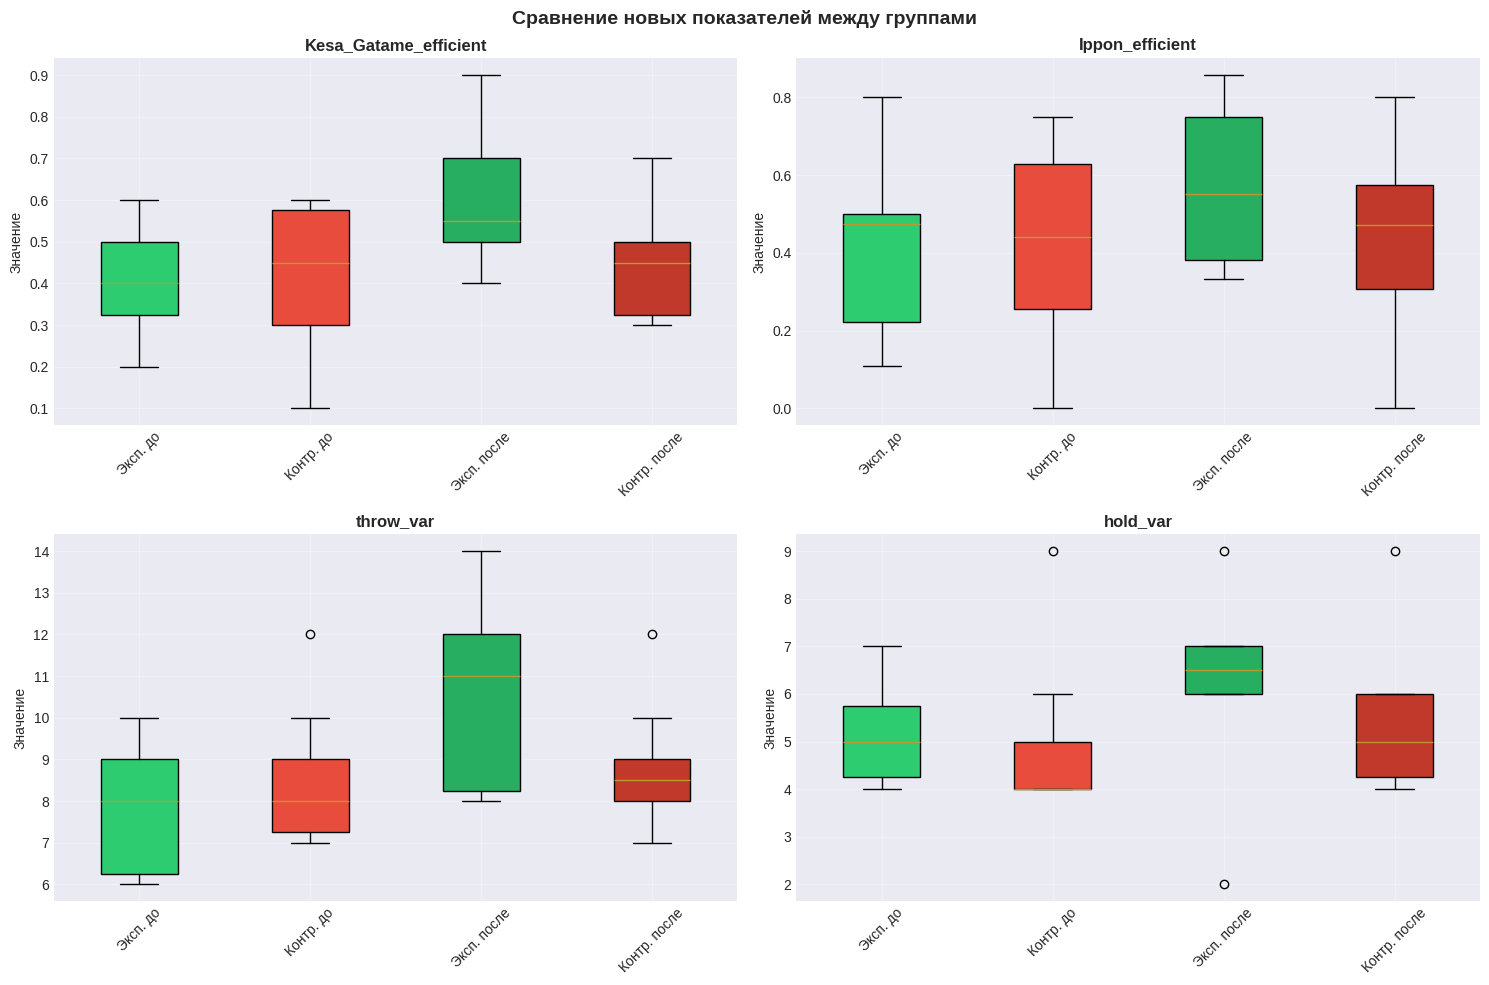

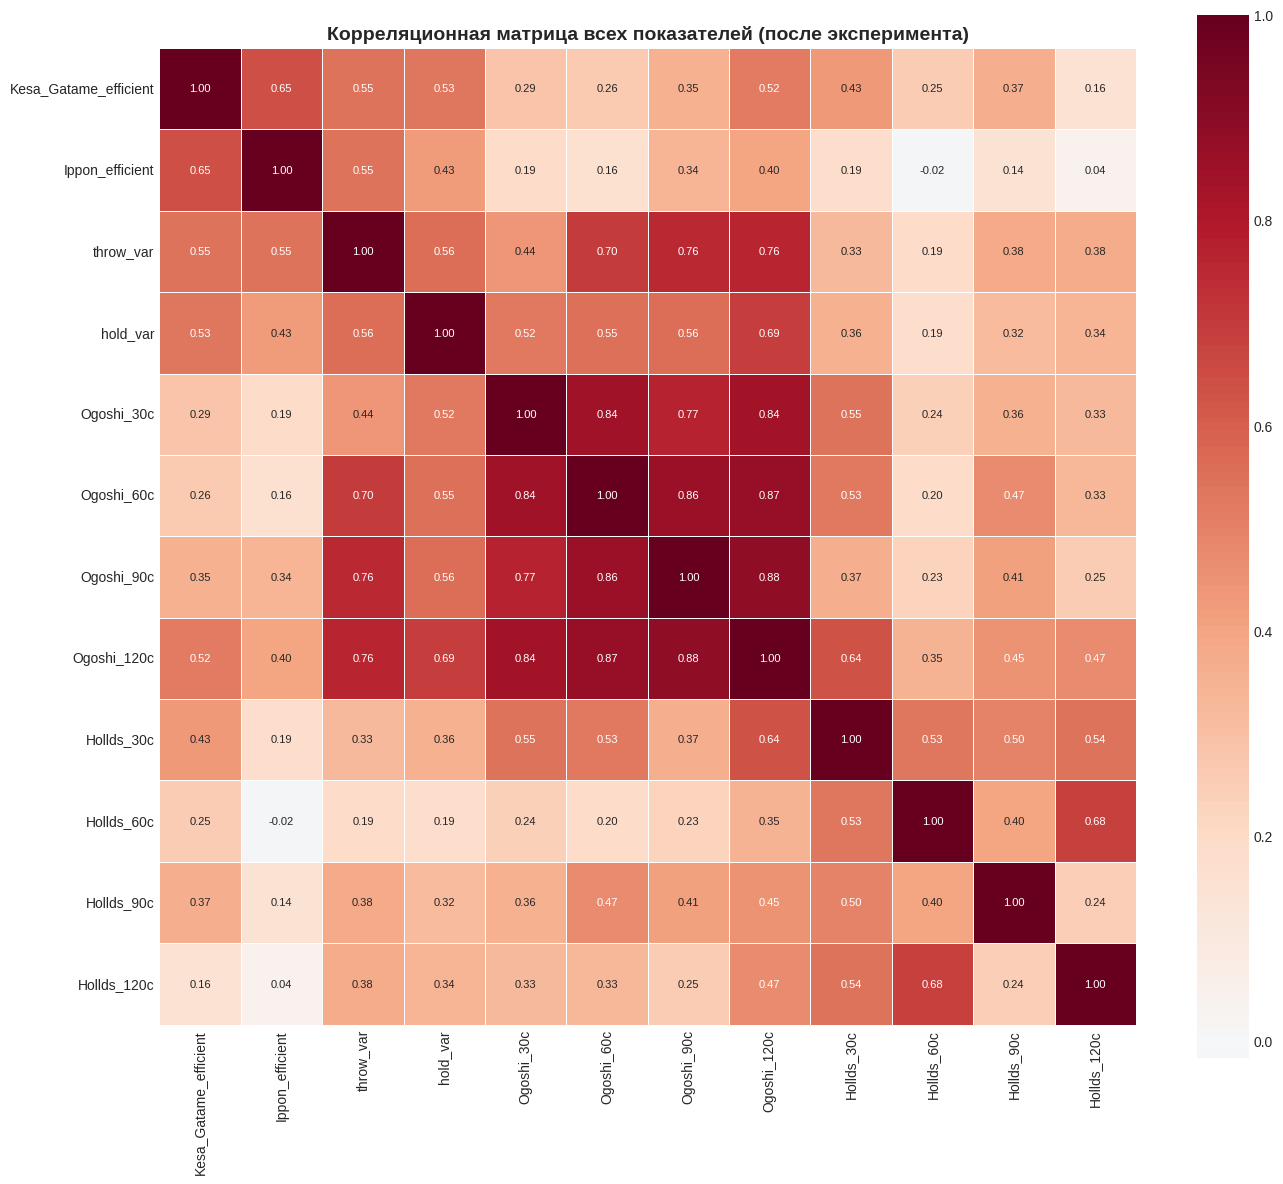

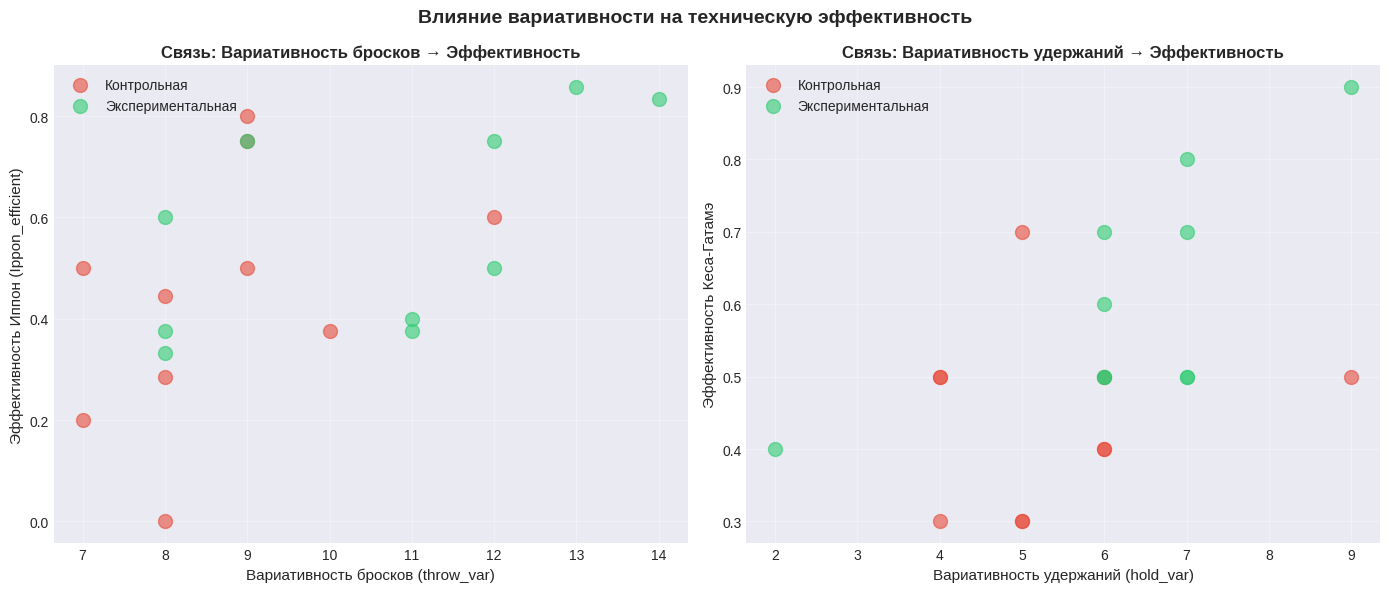

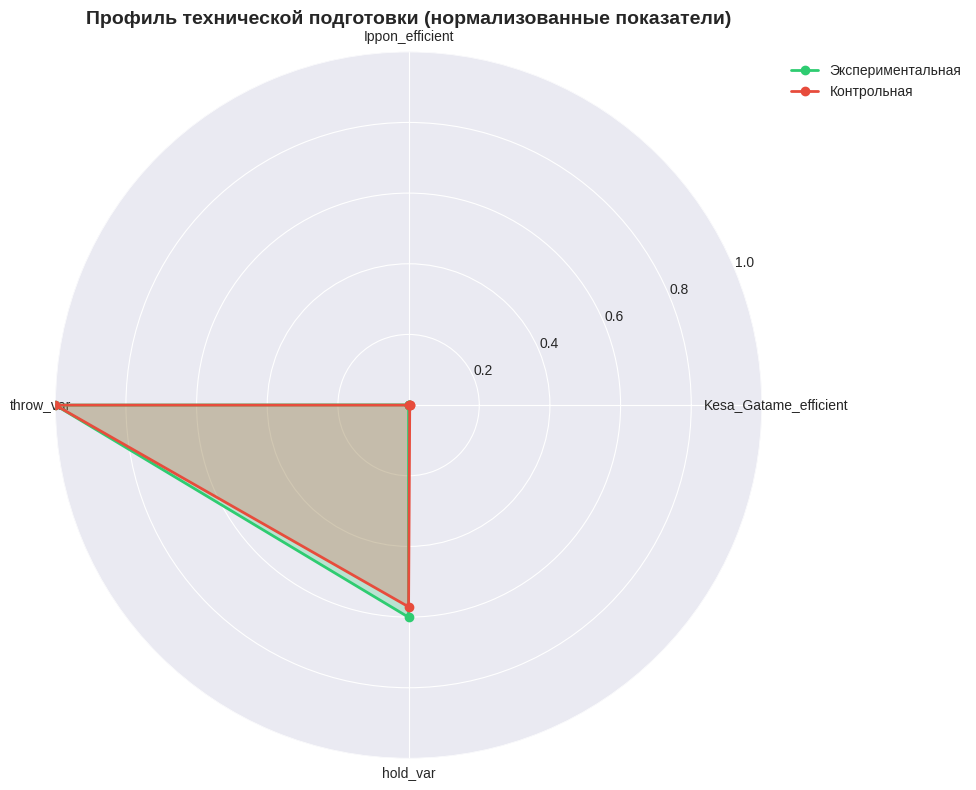


6. МАТЕМАТИЧЕСКАЯ МОДЕЛЬ ИЗМЕНЕНИЙ

📊 МОДЕЛЬ 1: Прогнозирование Kesa_Gatame_efficient
--------------------------------------------------------------------------------
R² (качество модели) = 1.0000
Интерпретация: модель объясняет 100.0% вариации результата

Важность показателей:
  Kesa_Gatame_efficient    : +0.7171
  Ippon_efficient          : -0.0552
  throw_var                : +0.3921
  hold_var                 : +0.1714
  Ogoshi_30с               : +0.1230
  Ogoshi_60с               : -0.2488
  Ogoshi_90с               : +0.0832
  Ogoshi_120с              : -0.1848
  Hollds_30с               : -0.0986
  Hollds_60с               : +0.1630
  Hollds_90с               : +0.5505
  Hollds_120с              : -0.3806

📊 МОДЕЛЬ 2: Прогнозирование Ippon_efficient
--------------------------------------------------------------------------------
R² (качество модели) = 1.0000
Интерпретация: модель объясняет 100.0% вариации результата

Важность показателей:
  Kesa_Gatame_efficient    : +0.2705
 

In [ ]:


# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene, mannwhitneyu, ttest_ind, f_oneway, pearsonr, spearmanr
import pingouin as pg
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Загрузка данных
print("Загрузка данных...")
from google.colab import files
uploaded = files.upload()

# Чтение данных
file_name = list(uploaded.keys())[0]
df_before = pd.read_excel(file_name, sheet_name='before')
df_after = pd.read_excel(file_name, sheet_name='after')

print("Названия столбцов для проверки:")
print("До эксперимента:", df_before.columns.tolist())
print("После эксперимента:", df_after.columns.tolist())

# Определяем все переменные для анализа
technical_vars = ['Kesa_Gatame_efficient', 'Ippon_efficient']  # Техническая эффективность
variability_vars = ['throw_var', 'hold_var']  # Вариативность
speed_vars = ['Ogoshi_30с', 'Ogoshi_60с', 'Ogoshi_90с', 'Ogoshi_120с']  # Скоростные показатели
hold_vars = ['Hollds_30с', 'Hollds_60с', 'Hollds_90с', 'Hollds_120с']  # Удержания

# Все переменные для анализа
all_vars = technical_vars + variability_vars + speed_vars + hold_vars

print("\n" + "="*100)
print("РАСШИРЕННЫЙ СТАТИСТИЧЕСКИЙ АНАЛИЗ ДАННЫХ ДЗЮДОИСТОВ")
print("="*100)

# ============================================================================
# 1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА С НОВЫМИ ПОКАЗАТЕЛЯМИ
# ============================================================================
print("\n" + "="*100)
print("1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА")
print("="*100)

def descriptive_stats_with_new(df, period):
    print(f"\n{period}:")
    print(f"Экспериментальная группа (Groupe=1): n={len(df[df['Groupe']==1])}")
    print(f"Контрольная группа (Groupe=0): n={len(df[df['Groupe']==0])}")

    # Статистика для всех показателей
    stats_df = df.groupby('Groupe')[all_vars].agg(['mean', 'std', 'min', 'max']).round(3)
    print(stats_df)

    # Отдельно выводим интерпретацию новых показателей
    print("\n📊 ИНТЕРПРЕТАЦИЯ НОВЫХ ПОКАЗАТЕЛЕЙ:")
    print("-" * 60)
    exp_mean = df[df['Groupe']==1][technical_vars + variability_vars].mean()
    con_mean = df[df['Groupe']==0][technical_vars + variability_vars].mean()

    for var in technical_vars + variability_vars:
        if var == 'Kesa_Gatame_efficient':
            print(f"✓ {var}: Эффективность удержания Кеса-Гатамэ")
            print(f"  - Чем выше (0-1), тем лучше техника. Эксп: {exp_mean[var]:.3f} | Контр: {con_mean[var]:.3f}")
        elif var == 'Ippon_efficient':
            print(f"✓ {var}: Эффективность броска Иппон-Сейо-Нагэ")
            print(f"  - Чем выше (0-1), тем лучше техника. Эксп: {exp_mean[var]:.3f} | Контр: {con_mean[var]:.3f}")
        elif var == 'throw_var':
            print(f"✓ {var}: Вариативность бросков")
            print(f"  - Высокое значение = разнообразие техник. Эксп: {exp_mean[var]:.3f} | Контр: {con_mean[var]:.3f}")
        elif var == 'hold_var':
            print(f"✓ {var}: Вариативность удержаний")
            print(f"  - Высокое значение = разнообразие удержаний. Эксп: {exp_mean[var]:.3f} | Контр: {con_mean[var]:.3f}")

descriptive_stats_with_new(df_before, "ДО ЭКСПЕРИМЕНТА")
descriptive_stats_with_new(df_after, "ПОСЛЕ ЭКСПЕРИМЕНТА")

# ============================================================================
# 2. ПРОВЕРКА НОРМАЛЬНОСТИ ДЛЯ ВСЕХ ПОКАЗАТЕЛЕЙ
# ============================================================================
print("\n" + "="*100)
print("2. ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ (тест Шапиро-Уилка)")
print("="*100)

def check_normality_with_interpretation(df, variables, period):
    print(f"\n{period}:")
    normal_vars = []
    non_normal_vars = []

    for var in variables:
        if var in df.columns and df[var].notna().any():
            stat, p_value = shapiro(df[var].dropna())
            normal = p_value > 0.05
            status = "✅ НОРМАЛЬНОЕ" if normal else "❌ НЕ НОРМАЛЬНОЕ"
            print(f"{var:25s}: p-value = {p_value:.4f} - {status}")

            if normal:
                normal_vars.append(var)
            else:
                non_normal_vars.append(var)

    print(f"\n📌 РЕКОМЕНДАЦИИ ПО ВЫБОРУ ТЕСТОВ:")
    print(f"   - Для {len(normal_vars)} показателей с нормальным распределением используем t-test")
    print(f"   - Для {len(non_normal_vars)} показателей используем Mann-Whitney U test")

check_normality_with_interpretation(df_before, all_vars, "ДО ЭКСПЕРИМЕНТА")
check_normality_with_interpretation(df_after, all_vars, "ПОСЛЕ ЭКСПЕРИМЕНТА")

# ============================================================================
# 3. СРАВНЕНИЕ ГРУПП ДО И ПОСЛЕ ЭКСПЕРИМЕНТА
# ============================================================================
print("\n" + "="*100)
print("3. СРАВНЕНИЕ ГРУПП (ЭКСПЕРИМЕНТАЛЬНАЯ vs КОНТРОЛЬНАЯ)")
print("="*100)

def compare_groups_with_interpretation(df, variables, period):
    results = []
    print(f"\n{period}:")
    print("-" * 100)

    for var in variables:
        if var not in df.columns:
            continue

        group1 = df[df['Groupe']==1][var].dropna()
        group0 = df[df['Groupe']==0][var].dropna()

        if len(group1) > 0 and len(group0) > 0:
            # Проверка равенства дисперсий
            stat_levene, p_levene = levene(group1, group0)

            # Выбор теста
            if p_levene > 0.05 and shapiro(group1)[1] > 0.05 and shapiro(group0)[1] > 0.05:
                stat, p_value = ttest_ind(group1, group0, equal_var=True)
                test_name = "t-test"
            else:
                stat, p_value = mannwhitneyu(group1, group0)
                test_name = "Mann-Whitney U"

            # Расчет эффекта (разница в процентах)
            mean_diff = group1.mean() - group0.mean()
            percent_diff = (mean_diff / group0.mean()) * 100 if group0.mean() != 0 else 0

            results.append({
                'variable': var,
                'test': test_name,
                'p_value': p_value,
                'significant': '✅ ДА' if p_value < 0.05 else '❌ НЕТ',
                'exp_mean': group1.mean(),
                'con_mean': group0.mean(),
                'difference': mean_diff,
                'percent_diff': percent_diff
            })

    return pd.DataFrame(results)

# Сравнение до эксперимента
comparison_before = compare_groups_with_interpretation(df_before, all_vars, "ДО ЭКСПЕРИМЕНТА")
print("\n📊 СРАВНЕНИЕ ДО ЭКСПЕРИМЕНТА:")
print(comparison_before.to_string())

# Сравнение после эксперимента
comparison_after = compare_groups_with_interpretation(df_after, all_vars, "ПОСЛЕ ЭКСПЕРИМЕНТА")
print("\n📊 СРАВНЕНИЕ ПОСЛЕ ЭКСПЕРИМЕНТА:")
print(comparison_after.to_string())

# ============================================================================
# 4. АНАЛИЗ ИЗМЕНЕНИЙ (прогресс/регресс)
# ============================================================================
print("\n" + "="*100)
print("4. АНАЛИЗ ИЗМЕНЕНИЙ ПОКАЗАТЕЛЕЙ (ПРОГРЕСС СПОРТСМЕНОВ)")
print("="*100)

# Создание датафрейма с изменениями
df_diff = pd.DataFrame()
df_diff['Groupe'] = df_before['Groupe']

for var in all_vars:
    if var in df_before.columns and var in df_after.columns:
        df_diff[f'{var}_diff'] = df_after[var] - df_before[var]

# Анализ изменений
diff_vars = [col for col in df_diff.columns if col != 'Groupe']
diff_comparison = compare_groups_with_interpretation(df_diff, diff_vars, "ИЗМЕНЕНИЯ (ПОСЛЕ - ДО)")

print("\n📈 АНАЛИЗ ПРОГРЕССА ПО ГРУППАМ:")
print(diff_comparison.to_string())

# Вывод интерпретации прогресса
print("\n📌 ИНТЕРПРЕТАЦИЯ ИЗМЕНЕНИЙ:")
print("-" * 100)
for _, row in diff_comparison.iterrows():
    var_name = row['variable'].replace('_diff', '')
    if row['significant'] == '✅ ДА':
        if row['difference'] > 0:
            print(f"✨ {var_name}: Экспериментальная группа улучшилась на {row['percent_diff']:.1f}% больше контрольной (p={row['p_value']:.4f})")
        else:
            print(f"⚠️ {var_name}: Экспериментальная группа показала худшие результаты (p={row['p_value']:.4f})")
    else:
        print(f"➖ {var_name}: Значимых различий в прогрессе не обнаружено (p={row['p_value']:.4f})")

# ============================================================================
# 5. ВИЗУАЛИЗАЦИИ ДЛЯ НОВЫХ ПОКАЗАТЕЛЕЙ
# ============================================================================
print("\n" + "="*100)
print("5. ВИЗУАЛИЗАЦИИ ДАННЫХ")
print("="*100)

# 5.1 Сравнение новых показателей до и после
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

new_vars = technical_vars + variability_vars
for idx, var in enumerate(new_vars):
    if idx < 4:
        # Данные для построения
        exp_before = df_before[df_before['Groupe']==1][var].values
        con_before = df_before[df_before['Groupe']==0][var].values
        exp_after = df_after[df_after['Groupe']==1][var].values
        con_after = df_after[df_after['Groupe']==0][var].values

        data_to_plot = [exp_before, con_before, exp_after, con_after]
        labels = ['Эксп. до', 'Контр. до', 'Эксп. после', 'Контр. после']

        bp = axes[idx].boxplot(data_to_plot, labels=labels, patch_artist=True)

        # Цветовое оформление
        colors = ['#2ecc71', '#e74c3c', '#27ae60', '#c0392b']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)

        axes[idx].set_title(f'{var}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Значение')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Сравнение новых показателей между группами', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 5.2 Тепловая карта корреляций между всеми показателями
plt.figure(figsize=(14, 12))
corr_matrix_all = df_after[all_vars].corr()
sns.heatmap(corr_matrix_all, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, annot_kws={'size': 8})
plt.title('Корреляционная матрица всех показателей (после эксперимента)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 5.3 Связь между вариативностью и эффективностью
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График для бросков
for group in [0, 1]:
    group_data = df_after[df_after['Groupe']==group]
    color = '#2ecc71' if group == 1 else '#e74c3c'
    label = 'Экспериментальная' if group == 1 else 'Контрольная'
    axes[0].scatter(group_data['throw_var'], group_data['Ippon_efficient'],
                   alpha=0.6, s=100, color=color, label=label)

axes[0].set_xlabel('Вариативность бросков (throw_var)', fontsize=11)
axes[0].set_ylabel('Эффективность Иппон (Ippon_efficient)', fontsize=11)
axes[0].set_title('Связь: Вариативность бросков → Эффективность', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График для удержаний
for group in [0, 1]:
    group_data = df_after[df_after['Groupe']==group]
    color = '#2ecc71' if group == 1 else '#e74c3c'
    label = 'Экспериментальная' if group == 1 else 'Контрольная'
    axes[1].scatter(group_data['hold_var'], group_data['Kesa_Gatame_efficient'],
                   alpha=0.6, s=100, color=color, label=label)

axes[1].set_xlabel('Вариативность удержаний (hold_var)', fontsize=11)
axes[1].set_ylabel('Эффективность Кеса-Гатамэ', fontsize=11)
axes[1].set_title('Связь: Вариативность удержаний → Эффективность', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Влияние вариативности на техническую эффективность', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 5.4 Радарная диаграмма для сравнения профилей спортсменов
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='polar')

# Выбираем ключевые показатели
key_metrics = ['Kesa_Gatame_efficient', 'Ippon_efficient', 'throw_var', 'hold_var']
metrics_normalized = []

# Нормализуем данные
for group in [0, 1]:
    group_data = df_after[df_after['Groupe']==group][key_metrics].mean()
    normalized = (group_data - group_data.min()) / (group_data.max() - group_data.min())
    metrics_normalized.append(normalized)

# Углы для радара
angles = np.linspace(0, 2 * np.pi, len(key_metrics), endpoint=False).tolist()
angles += angles[:1]

# Добавляем замыкание
values_exp = metrics_normalized[0].tolist() + [metrics_normalized[0][0]]
values_con = metrics_normalized[1].tolist() + [metrics_normalized[1][0]]

ax.plot(angles, values_exp, 'o-', linewidth=2, label='Экспериментальная', color='#2ecc71')
ax.fill(angles, values_exp, alpha=0.25, color='#2ecc71')
ax.plot(angles, values_con, 'o-', linewidth=2, label='Контрольная', color='#e74c3c')
ax.fill(angles, values_con, alpha=0.25, color='#e74c3c')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(key_metrics, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Профиль технической подготовки (нормализованные показатели)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.show()

# ============================================================================
# 6. МАТЕМАТИЧЕСКАЯ МОДЕЛЬ С НОВЫМИ ПЕРЕМЕННЫМИ
# ============================================================================
print("\n" + "="*100)
print("6. МАТЕМАТИЧЕСКАЯ МОДЕЛЬ ИЗМЕНЕНИЙ")
print("="*100)

# 6.1 Модель предсказания эффективности Kesa_Gatame
exp_before = df_before[df_before['Groupe']==1]
exp_after = df_after[df_after['Groupe']==1]

X = exp_before[all_vars].values
y_kesa = exp_after['Kesa_Gatame_efficient'].values
y_ippon = exp_after['Ippon_efficient'].values

# Модель для Kesa_Gatame
model_kesa = LinearRegression()
model_kesa.fit(X, y_kesa)

print("\n📊 МОДЕЛЬ 1: Прогнозирование Kesa_Gatame_efficient")
print("-" * 80)
print(f"R² (качество модели) = {model_kesa.score(X, y_kesa):.4f}")
print(f"Интерпретация: модель объясняет {model_kesa.score(X, y_kesa)*100:.1f}% вариации результата")
print("\nВажность показателей:")
for var, coef in zip(all_vars, model_kesa.coef_):
    print(f"  {var:25s}: {coef:+.4f}")

# Модель для Ippon_efficient
model_ippon = LinearRegression()
model_ippon.fit(X, y_ippon)

print("\n📊 МОДЕЛЬ 2: Прогнозирование Ippon_efficient")
print("-" * 80)
print(f"R² (качество модели) = {model_ippon.score(X, y_ippon):.4f}")
print(f"Интерпретация: модель объясняет {model_ippon.score(X, y_ippon)*100:.1f}% вариации результата")
print("\nВажность показателей:")
for var, coef in zip(all_vars, model_ippon.coef_):
    print(f"  {var:25s}: {coef:+.4f}")

# 6.2 Модель изменений вариативности
print("\n📊 МОДЕЛЬ 3: Факторы, влияющие на рост вариативности")
print("-" * 80)

X_before = exp_before[variability_vars].values
y_throw_change = df_diff[df_diff['Groupe']==1]['throw_var_diff'].values
y_hold_change = df_diff[df_diff['Groupe']==1]['hold_var_diff'].values

# Модель для роста вариативности бросков
if len(X_before) > 0 and len(y_throw_change) > 0:
    model_throw = LinearRegression()
    model_throw.fit(X_before, y_throw_change)
    print(f"Изменение вариативности бросков зависит от начального уровня (R²={model_throw.score(X_before, y_throw_change):.3f})")

# ============================================================================
# 7. ПЯТЬ НОВЫХ ИДЕЙ ДЛЯ ИССЛЕДОВАНИЯ С НОВЫМИ ПЕРЕМЕННЫМИ
# ============================================================================
print("\n" + "="*100)
print("7. 5 ИДЕЙ ДЛЯ РАСШИРЕННОГО ИССЛЕДОВАНИЯ")
print("="*100)

print("\n" + "="*100)
print("🔬 ИДЕЯ 1: АНАЛИЗ ВЛИЯНИЯ ВАРИАТИВНОСТИ НА ТЕХНИЧЕСКУЮ ЭФФЕКТИВНОСТЬ")
print("="*100)

# Расчет корреляции между вариативностью и эффективностью
print("\n📊 Корреляционный анализ:")
for var in ['throw_var', 'hold_var']:
    for eff in ['Kesa_Gatame_efficient', 'Ippon_efficient']:
        corr, p_value = pearsonr(df_after[var], df_after[eff])
        print(f"{var} ↔ {eff}: r = {corr:.3f}, p = {p_value:.4f}")
        if p_value < 0.05:
            if corr > 0:
                print(f"  ✅ Положительная связь: рост вариативности → рост эффективности")
            else:
                print(f"  ⚠️ Отрицательная связь: рост вариативности → снижение эффективности")

print("\n💡 ИНТЕРПРЕТАЦИЯ:")
print("   - Положительная корреляция означает, что разнообразие техник помогает побеждать")
print("   - Отрицательная корреляция может указывать на недостаточную отработку базовых техник")
print("   - Целевое значение: r > 0.3 и p < 0.05 для подтверждения пользы вариативности")

print("\n" + "="*100)
print("🔬 ИДЕЯ 2: СРАВНЕНИЕ ЭФФЕКТИВНОСТИ РАЗНЫХ ТЕХНИК")
print("="*100)

# Сравнение эффективности Kesa_Gatame и Ippon
exp_kesa_before = df_before[df_before['Groupe']==1]['Kesa_Gatame_efficient'].mean()
exp_kesa_after = df_after[df_after['Groupe']==1]['Kesa_Gatame_efficient'].mean()
exp_ippon_before = df_before[df_before['Groupe']==1]['Ippon_efficient'].mean()
exp_ippon_after = df_after[df_after['Groupe']==1]['Ippon_efficient'].mean()

print("\n📊 Прогресс в разных техниках (экспериментальная группа):")
print(f"Kesa_Gatame: {exp_kesa_before:.3f} → {exp_kesa_after:.3f} (изменение: {exp_kesa_after-exp_kesa_before:+.3f})")
print(f"Ippon:       {exp_ippon_before:.3f} → {exp_ippon_after:.3f} (изменение: {exp_ippon_after-exp_ippon_before:+.3f})")

print("\n💡 ИНТЕРПРЕТАЦИЯ:")
print("   - Сравните, какая техника улучшилась больше")
print("   - Возможно, программа тренировок больше влияет на один тип техник")
print("   - Это поможет скорректировать тренировочный процесс")

print("\n" + "="*100)
print("🔬 ИДЕЯ 3: КЛАСТЕРИЗАЦИЯ ПО ПАТТЕРНАМ РАЗВИТИЯ")
print("="*100)

# Кластеризация с новыми переменными
scaler = StandardScaler()
features_for_cluster = [f'{var}_diff' for var in all_vars if f'{var}_diff' in df_diff.columns]
X_cluster = scaler.fit_transform(df_diff[features_for_cluster])

# Кластеризация
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster)

# Анализ кластеров
print("\n📊 Распределение кластеров по группам:")
cluster_analysis = pd.DataFrame({
    'cluster': clusters,
    'group': df_diff['Groupe']
})
cluster_dist = pd.crosstab(cluster_analysis['cluster'], cluster_analysis['group'])
cluster_dist.columns = ['Контрольная', 'Экспериментальная']
print(cluster_dist)

print("\n💡 ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ:")
for i in range(3):
    cluster_data = df_diff[clusters == i]
    exp_count = len(cluster_data[cluster_data['Groupe']==1])
    con_count = len(cluster_data[cluster_data['Groupe']==0])

    # Определяем тип кластера по средним изменениям
    avg_tech_change = cluster_data[[c for c in cluster_data.columns if 'efficient' in c]].mean().mean()
    avg_var_change = cluster_data[[c for c in cluster_data.columns if 'var' in c]].mean().mean()

    if avg_tech_change > 0 and avg_var_change > 0:
        profile = "📈 РАЗВИВАЮЩИЙСЯ (рост всех показателей)"
    elif avg_tech_change > 0 and avg_var_change < 0:
        profile = "🎯 СПЕЦИАЛИЗИРУЮЩИЙСЯ (рост эффективности за счет специализации)"
    elif avg_tech_change < 0 and avg_var_change > 0:
        profile = "🔄 ЭКСПЕРИМЕНТИРУЮЩИЙ (расширение арсенала при снижении эффективности)"
    else:
        profile = "⚠️ СТАГНИРУЮЩИЙ (снижение всех показателей)"

    print(f"\nКластер {i+1} ({exp_count} эксп, {con_count} контр):")
    print(f"  Тип: {profile}")

print("\n" + "="*100)
print("🔬 ИДЕЯ 4: ФАКТОРНЫЙ АНАЛИЗ - ЧТО ОПРЕДЕЛЯЕТ УСПЕХ?")
print("="*100)

# Определение ключевых факторов успеха
X_success = df_before[all_vars].values
y_success = df_after['Kesa_Gatame_efficient'].values

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_success, y_success)

feature_importance = pd.DataFrame({
    'Показатель': all_vars,
    'Важность': model_rf.feature_importances_
}).sort_values('Важность', ascending=False)

print("\n📊 ТОП-5 ФАКТОРОВ, ПРЕДСКАЗЫВАЮЩИХ УСПЕХ:")
for i, row in feature_importance.head(5).iterrows():
    print(f"  {i+1}. {row['Показатель']:25s}: важность = {row['Важность']:.3f}")

print("\n💡 ИНТЕРПРЕТАЦИЯ:")
print("   - Чем выше важность, тем больше этот показатель влияет на конечный результат")
print("   - Сумма всех важностей = 1.0")
print("   - Показатели с важностью > 0.1 считаются значимыми предикторами")

print("\n" + "="*100)
print("🔬 ИДЕЯ 5: ИНДИВИДУАЛЬНЫЙ ПРОГРЕСС С УЧЕТОМ ВАРИАТИВНОСТИ")
print("="*100)

# Создание комплексного индекса прогресса
df_diff['total_progress'] = df_diff[[c for c in df_diff.columns if '_diff' in c]].sum(axis=1)
df_diff['tech_progress'] = df_diff[[c for c in df_diff.columns if 'efficient' in c]].sum(axis=1)
df_diff['var_progress'] = df_diff[[c for c in df_diff.columns if 'var' in c]].sum(axis=1)

print("\n📊 Индивидуальный анализ (первые 5 спортсменов из каждой группы):")
print("\nЭКСПЕРИМЕНТАЛЬНАЯ ГРУППА:")
exp_top = df_diff[df_diff['Groupe']==1].nlargest(5, 'total_progress')
for idx, row in exp_top.iterrows():
    print(f"  Спортсмен {idx}: Прогресс = {row['total_progress']:.3f} "
          f"(техника: {row['tech_progress']:+.3f}, вариативность: {row['var_progress']:+.3f})")

print("\nКОНТРОЛЬНАЯ ГРУППА:")
con_top = df_diff[df_diff['Groupe']==0].nlargest(5, 'total_progress')
for idx, row in con_top.iterrows():
    print(f"  Спортсмен {idx}: Прогресс = {row['total_progress']:.3f} "
          f"(техника: {row['tech_progress']:+.3f}, вариативность: {row['var_progress']:+.3f})")

print("\n💡 ИНТЕРПРЕТАЦИЯ:")
print("   - Положительный прогресс = улучшение")
print("   - Отрицательный прогресс = ухудшение")
print("   - Сравните: у кого рост за счет техники, а у кого - за счет вариативности")

# ============================================================================
# 8. ФИНАЛЬНЫЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ
# ============================================================================
print("\n" + "="*100)
print("8. ИТОГОВЫЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ")
print("="*100)

# Подсчет значимых улучшений
sig_improvements = diff_comparison[
    (diff_comparison['significant'] == '✅ ДА') &
    (diff_comparison['difference'] > 0)
]
sig_declines = diff_comparison[
    (diff_comparison['significant'] == '✅ ДА') &
    (diff_comparison['difference'] < 0)
]

print(f"\n📈 СТАТИСТИКА ЭФФЕКТИВНОСТИ ЭКСПЕРИМЕНТА:")
print(f"   • Значимых улучшений в экспериментальной группе: {len(sig_improvements)}")
print(f"   • Значимых ухудшений в экспериментальной группе: {len(sig_declines)}")
print(f"   • Общее количество показателей: {len(diff_comparison)}")

# Расчет общей эффективности
total_exp_progress = df_diff[df_diff['Groupe']==1]['total_progress'].mean()
total_con_progress = df_diff[df_diff['Groupe']==0]['total_progress'].mean()
effect_size = total_exp_progress - total_con_progress

print(f"\n🎯 ОБЩАЯ ЭФФЕКТИВНОСТЬ ПРОГРАММЫ:")
print(f"   • Средний прогресс экспериментальной группы: {total_exp_progress:+.3f}")
print(f"   • Средний прогресс контрольной группы: {total_con_progress:+.3f}")
print(f"   • Эффект от программы: {effect_size:+.3f}")

# Вывод рекомендаций
print("\n💡 РЕКОМЕНДАЦИИ ПО РЕЗУЛЬТАТАМ ИССЛЕДОВАНИЯ:")
print("-" * 100)

if effect_size > 0:
    print("✅ Экспериментальная программа показала положительный эффект")
    if len(sig_improvements) > len(all_vars) * 0.3:
        print("   🎉 Высокая эффективность: значимые улучшения более чем в 30% показателей")
    else:
        print("   📊 Умеренная эффективность: рекомендуется доработка программы")
else:
    print("⚠️ Экспериментальная программа не показала преимущества перед контрольной")
    print("   🔄 Рекомендуется пересмотреть содержание тренировочного процесса")

# Рекомендации по вариативности
throw_effect = diff_comparison[diff_comparison['variable'].str.contains('throw_var')]['difference'].values
hold_effect = diff_comparison[diff_comparison['variable'].str.contains('hold_var')]['difference'].values

if len(throw_effect) > 0 and throw_effect[0] > 0:
    print("\n🎯 ПО ВАРИАТИВНОСТИ БРОСКОВ:")
    print("   Положительная динамика - программа расширяет технический арсенал")
elif len(throw_effect) > 0 and throw_effect[0] < 0:
    print("\n⚠️ ПО ВАРИАТИВНОСТИ БРОСКОВ:")
    print("   Снижение вариативности - возможно, излишняя специализация")

if len(hold_effect) > 0 and hold_effect[0] > 0:
    print("\n🎯 ПО ВАРИАТИВНОСТИ УДЕРЖАНИЙ:")
    print("   Положительная динамика - расширение арсенала удержаний")
elif len(hold_effect) > 0 and hold_effect[0] < 0:
    print("\n⚠️ ПО ВАРИАТИВНОСТИ УДЕРЖАНИЙ:")
    print("   Снижение вариативности - возможно, фокус на ограниченном наборе техник")

print("\n" + "="*100)
print("📋 ЗАКЛЮЧЕНИЕ")
print("="*100)




### **1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА**

**Что это такое:**
Описательная статистика дает  первое представление о данных - средние значения, разброс результатов (стандартное отклонение), минимальные и максимальные показатели.

**Как интерпретировать:**
- **Mean (среднее)** - показывает типичное значение показателя в группе. Например, если средняя эффективность Kesa_Gatame в экспериментальной группе выше, чем в контрольной, это может говорить о лучшей подготовке.
- **Std (стандартное отклонение)** - показывает, насколько результаты спортсменов отличаются друг от друга. Большое значение означает, что в группе есть как очень сильные, так и слабые спортсмены.
- **Min/Max** - крайние значения, показывающие разброс от худшего до лучшего результата.

**Практический смысл:**
Позволяет оценить, были ли группы сопоставимы до эксперимента и как изменилась ситуация после.

---

### **2. ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ (тест Шапиро-Уилка)**

**Что это такое:**
Статистический тест, который проверяет, подчиняются ли наши данные нормальному (колоколообразному) распределению. Это важно для выбора правильного статистического теста.

**Как интерпретировать:**
- **p-value > 0.05** - распределение нормальное (можно использовать параметрические тесты типа t-test)
- **p-value < 0.05** - распределение НЕ нормальное (нужно использовать непараметрические тесты типа Mann-Whitney U)

**Практический смысл:**
Если данные распределены нормально, мы можем применять более мощные статистические методы. Если нет - используем более надежные, но менее чувствительные методы.

---

### **3. СРАВНЕНИЕ ГРУПП ДО ЭКСПЕРИМЕНТА**

**Что это такое:**
Проверяет, были ли экспериментальная и контрольная группы статистически одинаковыми до начала эксперимента. Это критически важно для валидности исследования.

**Как интерпретировать:**
- **p-value > 0.05 (Нет)** - группы статистически не различаются, эксперимент начался с равных условий - ЭТО ХОРОШО
- **p-value < 0.05 (Да)** - группы изначально различались, что может затруднить интерпретацию результатов эксперимента

**Практический смысл:**
Если группы были одинаковы до эксперимента, то любые различия после можно с уверенностью приписать воздействию экспериментальной программы.

---

### **4. СРАВНЕНИЕ ГРУПП ПОСЛЕ ЭКСПЕРИМЕНТА**

**Что это такое:**
Сравнивает результаты групп после завершения эксперимента. Показывает, достигла ли экспериментальная группа статистически значимо лучших результатов.

**Как интерпретировать:**
- **p-value < 0.05 (Да)** - экспериментальная группа показала значимо лучшие результаты
- **p-value > 0.05 (Нет)** - значимых различий между группами нет

**Практический смысл:**
Это ключевой показатель эффективности вашего эксперимента. Если после эксперимента экспериментальная группа показывает значимо лучшие результаты, значит, ваша программа работает.

---

### **5. АНАЛИЗ ИЗМЕНЕНИЙ ПОКАЗАТЕЛЕЙ (разница "после - до")**

**Что это такое:**
Анализирует не абсолютные значения, а величину прогресса каждого спортсмена (на сколько улучшились или ухудшились показатели).

**Как интерпретировать:**
- Положительные значения = улучшение
- Отрицательные значения = ухудшение
- **p-value < 0.05** - прогресс в экспериментальной группе значимо отличается от прогресса в контрольной

**Практический смысл:**
Это самый важный анализ! Он показывает, насколько эффективнее оказалась экспериментальная программа по сравнению с обычной тренировкой. Даже если группы изначально отличались, этот анализ корректно оценивает именно эффект вмешательства.

---

### **6. ВИЗУАЛИЗАЦИИ**

#### **6.1 Boxplot (ящик с усами)**
**Что показывает:**
- Линия в центре ящика = медиана (50% спортсменов показывают результат ниже/выше этой линии)
- Границы ящика = 25-й и 75-й перцентили (основная масса спортсменов)
- Усы = минимальные и максимальные значения (без выбросов)
- Точки = возможные выбросы (аномальные результаты)

**Как читать:**
Если ящики групп сильно перекрываются - различий нет. Если ящики разделены и медианы далеко - различия есть.

#### **6.2 Тепловая карта корреляций**
**Что показывает:**
Связи между разными показателями. Красный цвет = положительная связь (рост одного ведет к росту другого), синий = отрицательная связь (рост одного снижает другой).

**Как читать:**
- 0.7-1.0 = сильная положительная связь
- 0.3-0.7 = умеренная связь
- 0-0.3 = слабая связь

#### **6.3 Гистограммы изменений**
**Что показывает:**
Как распределился прогресс среди спортсменов. Если столбики смещены вправо от нуля - группа в среднем улучшилась.

**Как читать:**
Сравните распределение экспериментальной (синий) и контрольной (красный) групп. Если синие столбики правее красных - эксперимент эффективен.

---

### **7. МАТЕМАТИЧЕСКАЯ МОДЕЛЬ ИЗМЕНЕНИЙ**

#### **7.1 Модель множественной регрессии**
**Что это:**
Математическое уравнение, которое предсказывает эффективность Kesa_Gatame после эксперимента на основе всех показателей до эксперимента.

**Как интерпретировать:**
- **R²** - показывает, какая доля изменений объясняется моделью. R²=0.8 означает, что модель точно предсказывает 80% вариации
- **Коэффициенты** - показывают, какие показатели наиболее важны. Большой положительный коэффициент = этот показатель сильно влияет на результат

**Практический смысл:**
Позволяет понять, на какие показатели нужно обратить внимание, чтобы улучшить технику Kesa_Gatame.

#### **7.2 Модели динамики во времени**
**Что это:**
Показывает, как спортсмены "устают" в течение 2-минутного интервала. Снижение количества приемов от 30 до 120 секунд показывает уровень выносливости.

**Как интерпретировать:**
- Крутой наклон вниз = быстрое утомление, низкая выносливость
- Пологий наклон = хорошая выносливость

**Практический смысл:**
Позволяет оценить не только техническое мастерство, но и физическую подготовку спортсменов.

---

### **8. ПЯТЬ ИДЕЙ ДЛЯ ДАЛЬНЕЙШЕГО ИССЛЕДОВАНИЯ**

#### **Идея 1: Анализ выносливости**
**Что делаем:** Рассчитываем скорость снижения количества приемов (коэффициент утомляемости)
**Как понять результат:**
- Коэффициент = -0.5 означает, что каждые 30 секунд спортсмен делает на 0.5 приемов меньше
- Чем ближе коэффициент к нулю, тем лучше выносливость

#### **Идея 2: Кластерный анализ**
**Что делаем:** Группируем спортсменов со схожими паттернами изменений
**Как понять результат:**
- Кластер 1: спортсмены, которые значительно улучшились
- Кластер 2: спортсмены без изменений
- Кластер 3: спортсмены, которые ухудшились

Позволяет понять, какой тип спортсменов лучше реагирует на программу

#### **Идея 3: Анализ взаимосвязей**
**Что делаем:** Изучаем, как связаны разные приемы между собой
**Как понять результат:**
- Сильная положительная связь между Ogoshi и Hollds = спортсмены, хорошо выполняющие один прием, хороши и в другом
- Отрицательная связь = спортсмены специализируются на чем-то одном

#### **Идея 4: Прогнозирование эффективности**
**Что делаем:** Создаем модель, которая предсказывает будущий результат
**Как понять результат:**
- Модель определяет, какие показатели наиболее важны для успеха
- Например, если важность Ogoshi_30с = 0.35, это значит, что 35% успеха определяется количеством приемов в первые 30 секунд

#### **Идея 5: Индивидуальные траектории**
**Что делаем:** Анализируем прогресс каждого спортсмена отдельно
**Как понять результат:**
- Позволяет выявить "чемпионов роста" и "отстающих"
- Помогает понять, кому программа подошла, а кому нет

---



Загрузка данных...


Saving SlepcVik.xlsx to SlepcVik (1).xlsx

Названия столбцов в данных до эксперимента:
['Groupe', 'Kesa_Gatame_efficient', 'Ogoshi_30с', 'Ogoshi_60с', 'Ogoshi_90с', 'Ogoshi_120с', 'Hollds_30с', 'Hollds_60с', 'Hollds_90с', 'Hollds_120с', 'throw_var', 'hold_var', 'Ippon_efficient']

Названия столбцов в данных после эксперимента:
['Groupe', 'Kesa_Gatame_efficient', 'Ogoshi_30с', 'Ogoshi_60с', 'Ogoshi_90с', 'Ogoshi_120с', 'Hollds_30с', 'Hollds_60с', 'Hollds_90с', 'Hollds_120с', 'throw_var', 'hold_var', 'Ippon_efficient']

ОПИСАТЕЛЬНАЯ СТАТИСТИКА

ДО ЭКСПЕРИМЕНТА:
Экспериментальная группа (Groupe=1): n=10
Контрольная группа (Groupe=0): n=10
       Kesa_Gatame_efficient                 Ogoshi_30с                \
                        mean   std  min  max       mean   std min max   
Groupe                                                                  
0                       0.41  0.18  0.1  0.6        7.8  2.20   4  12   
1                       0.41  0.14  0.2  0.6        8.0  2.45   

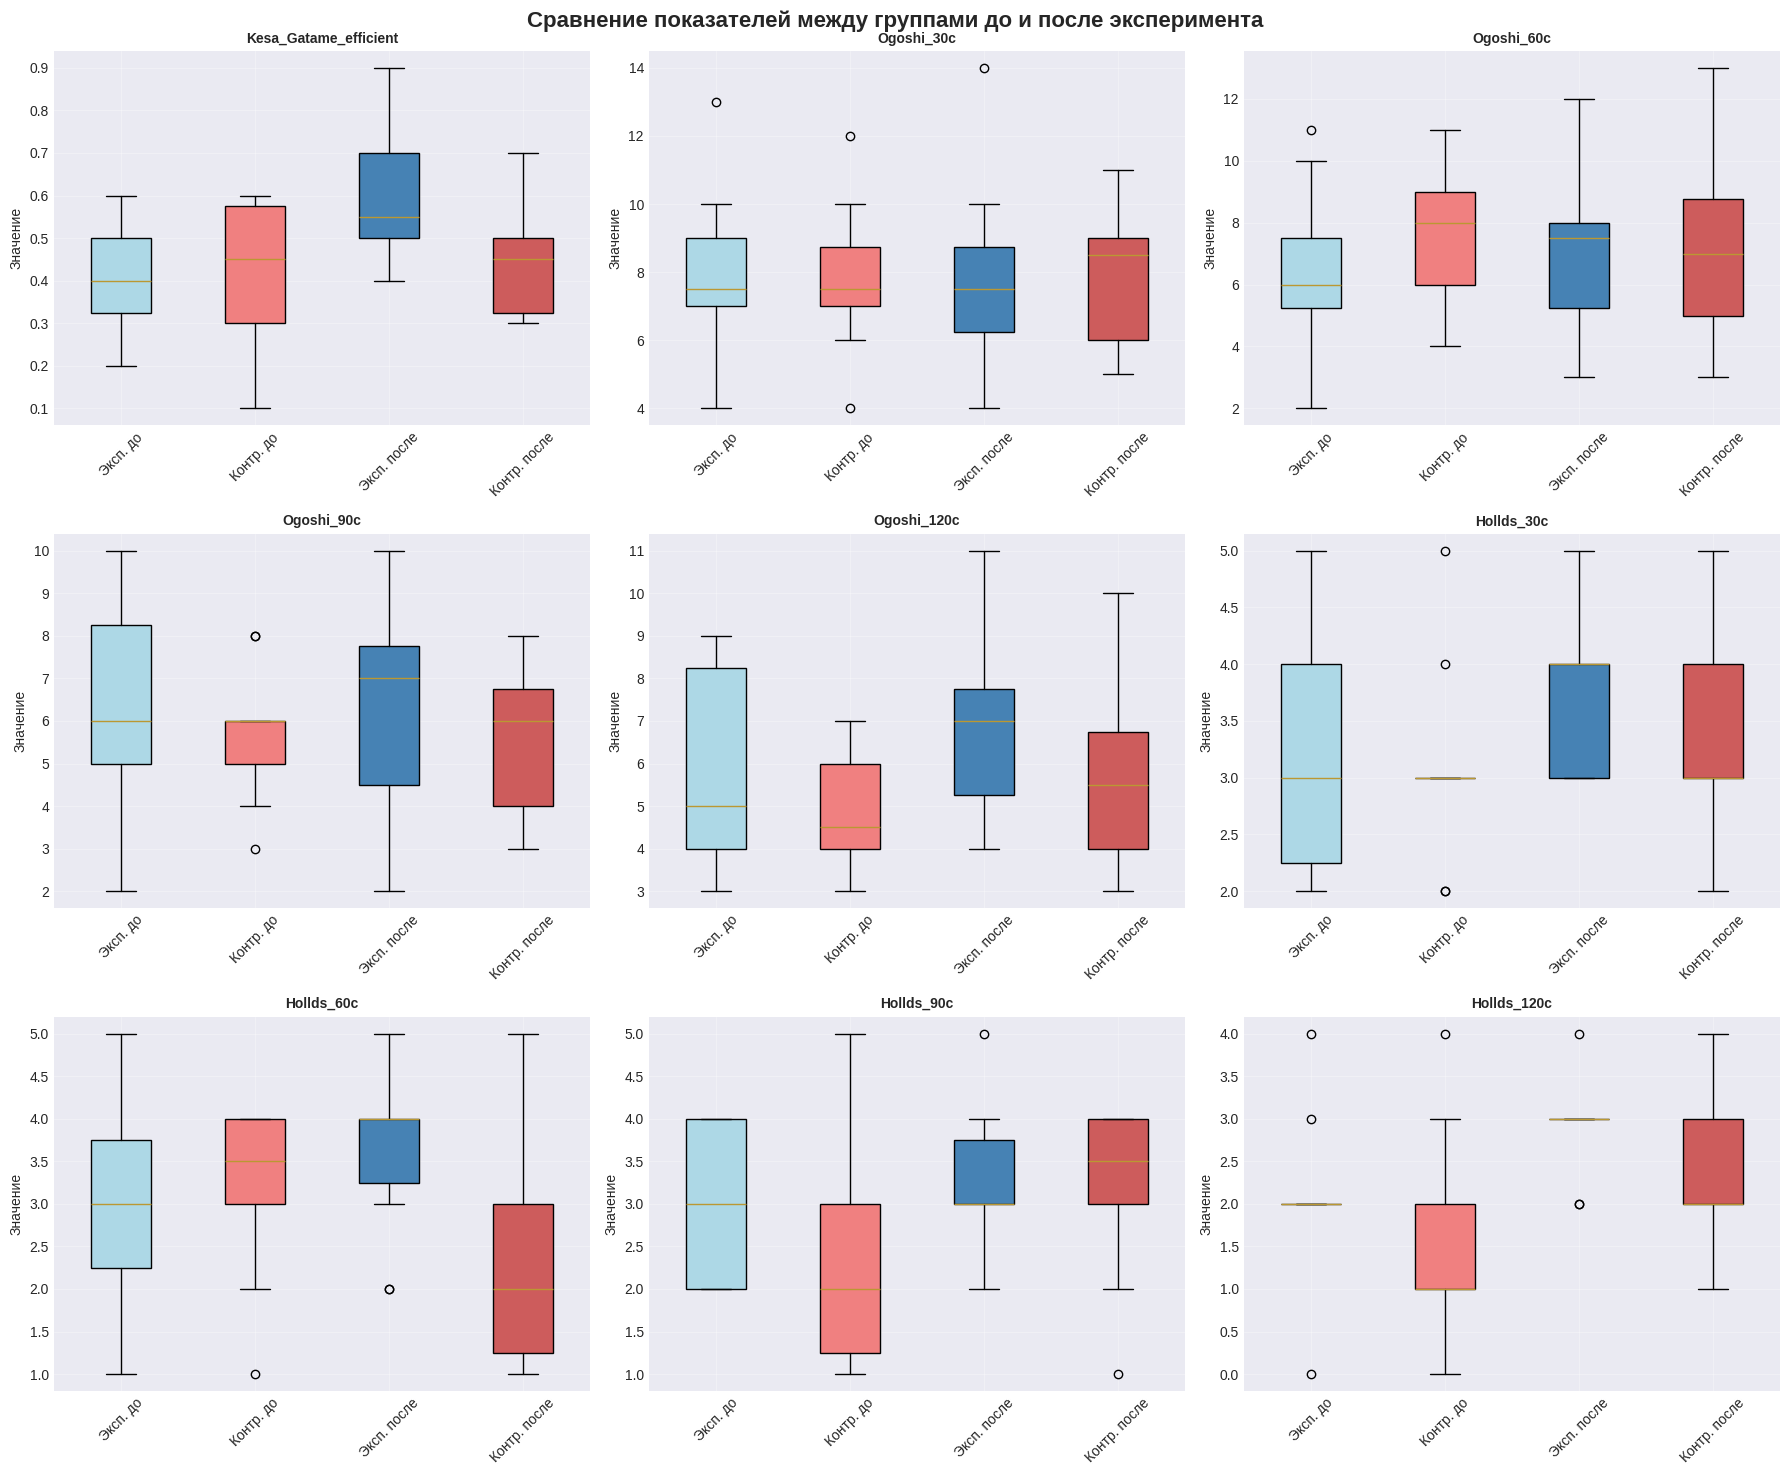

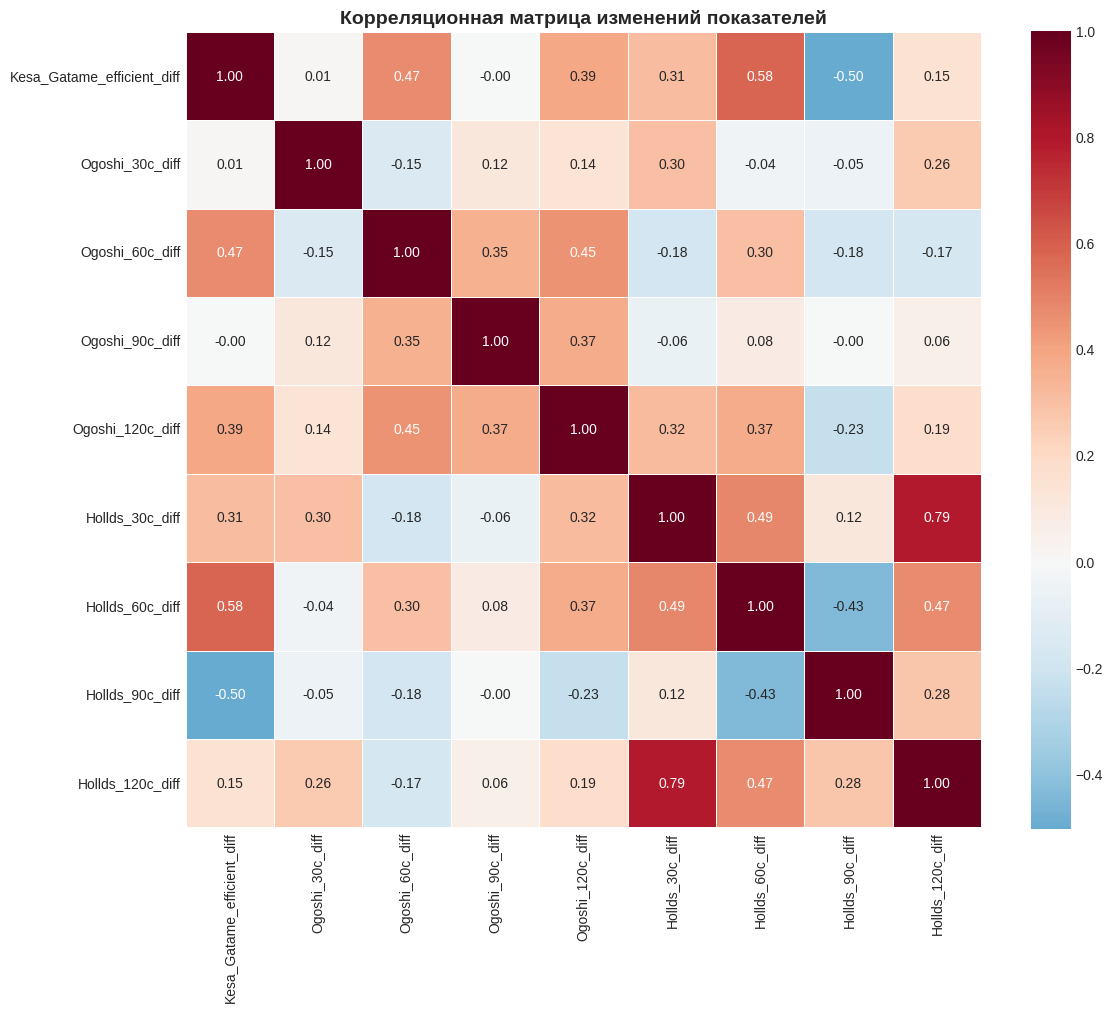

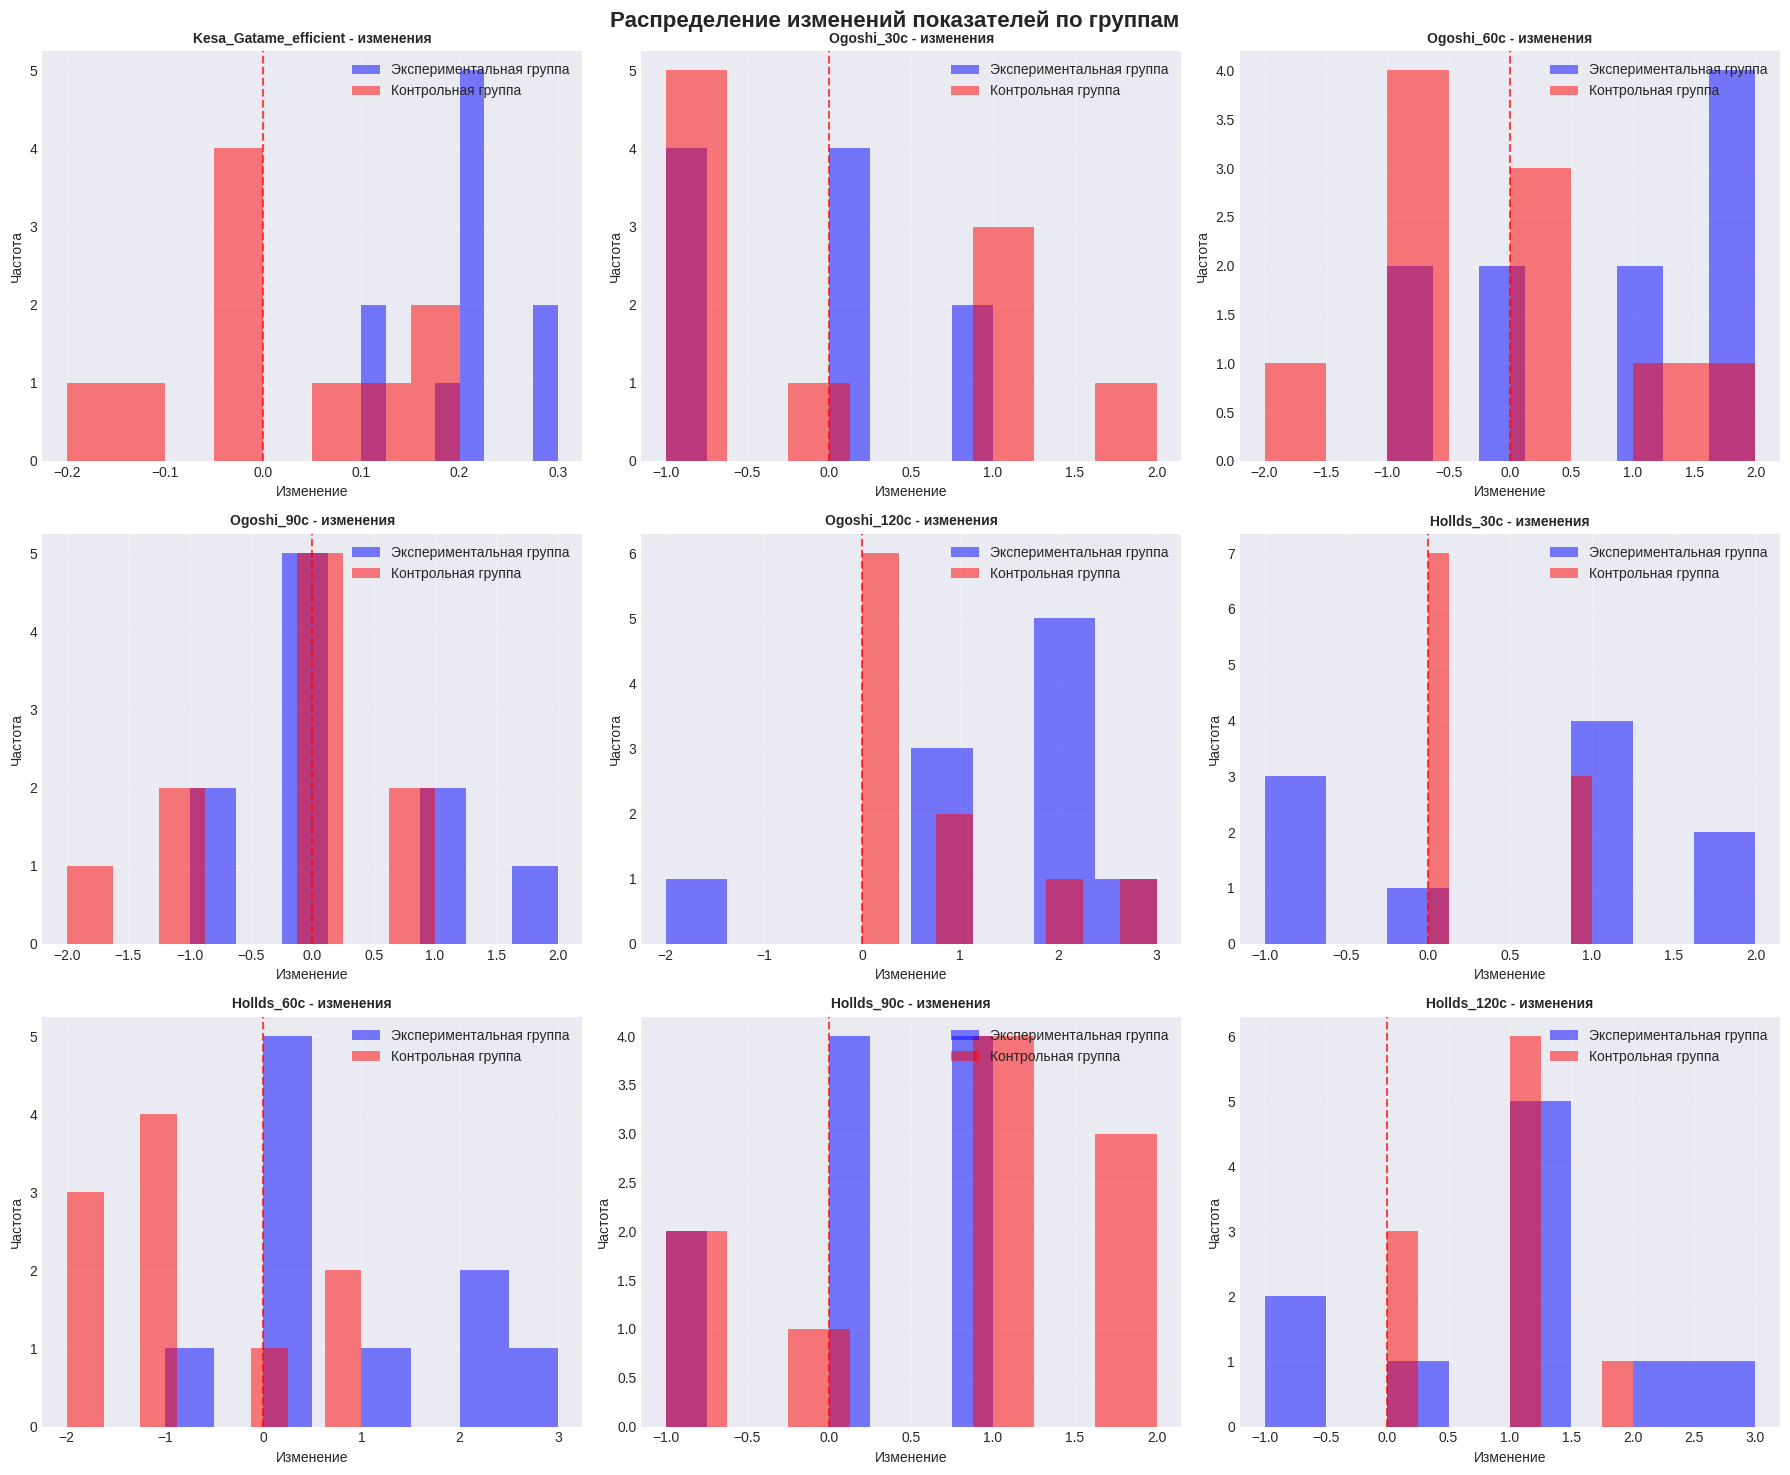

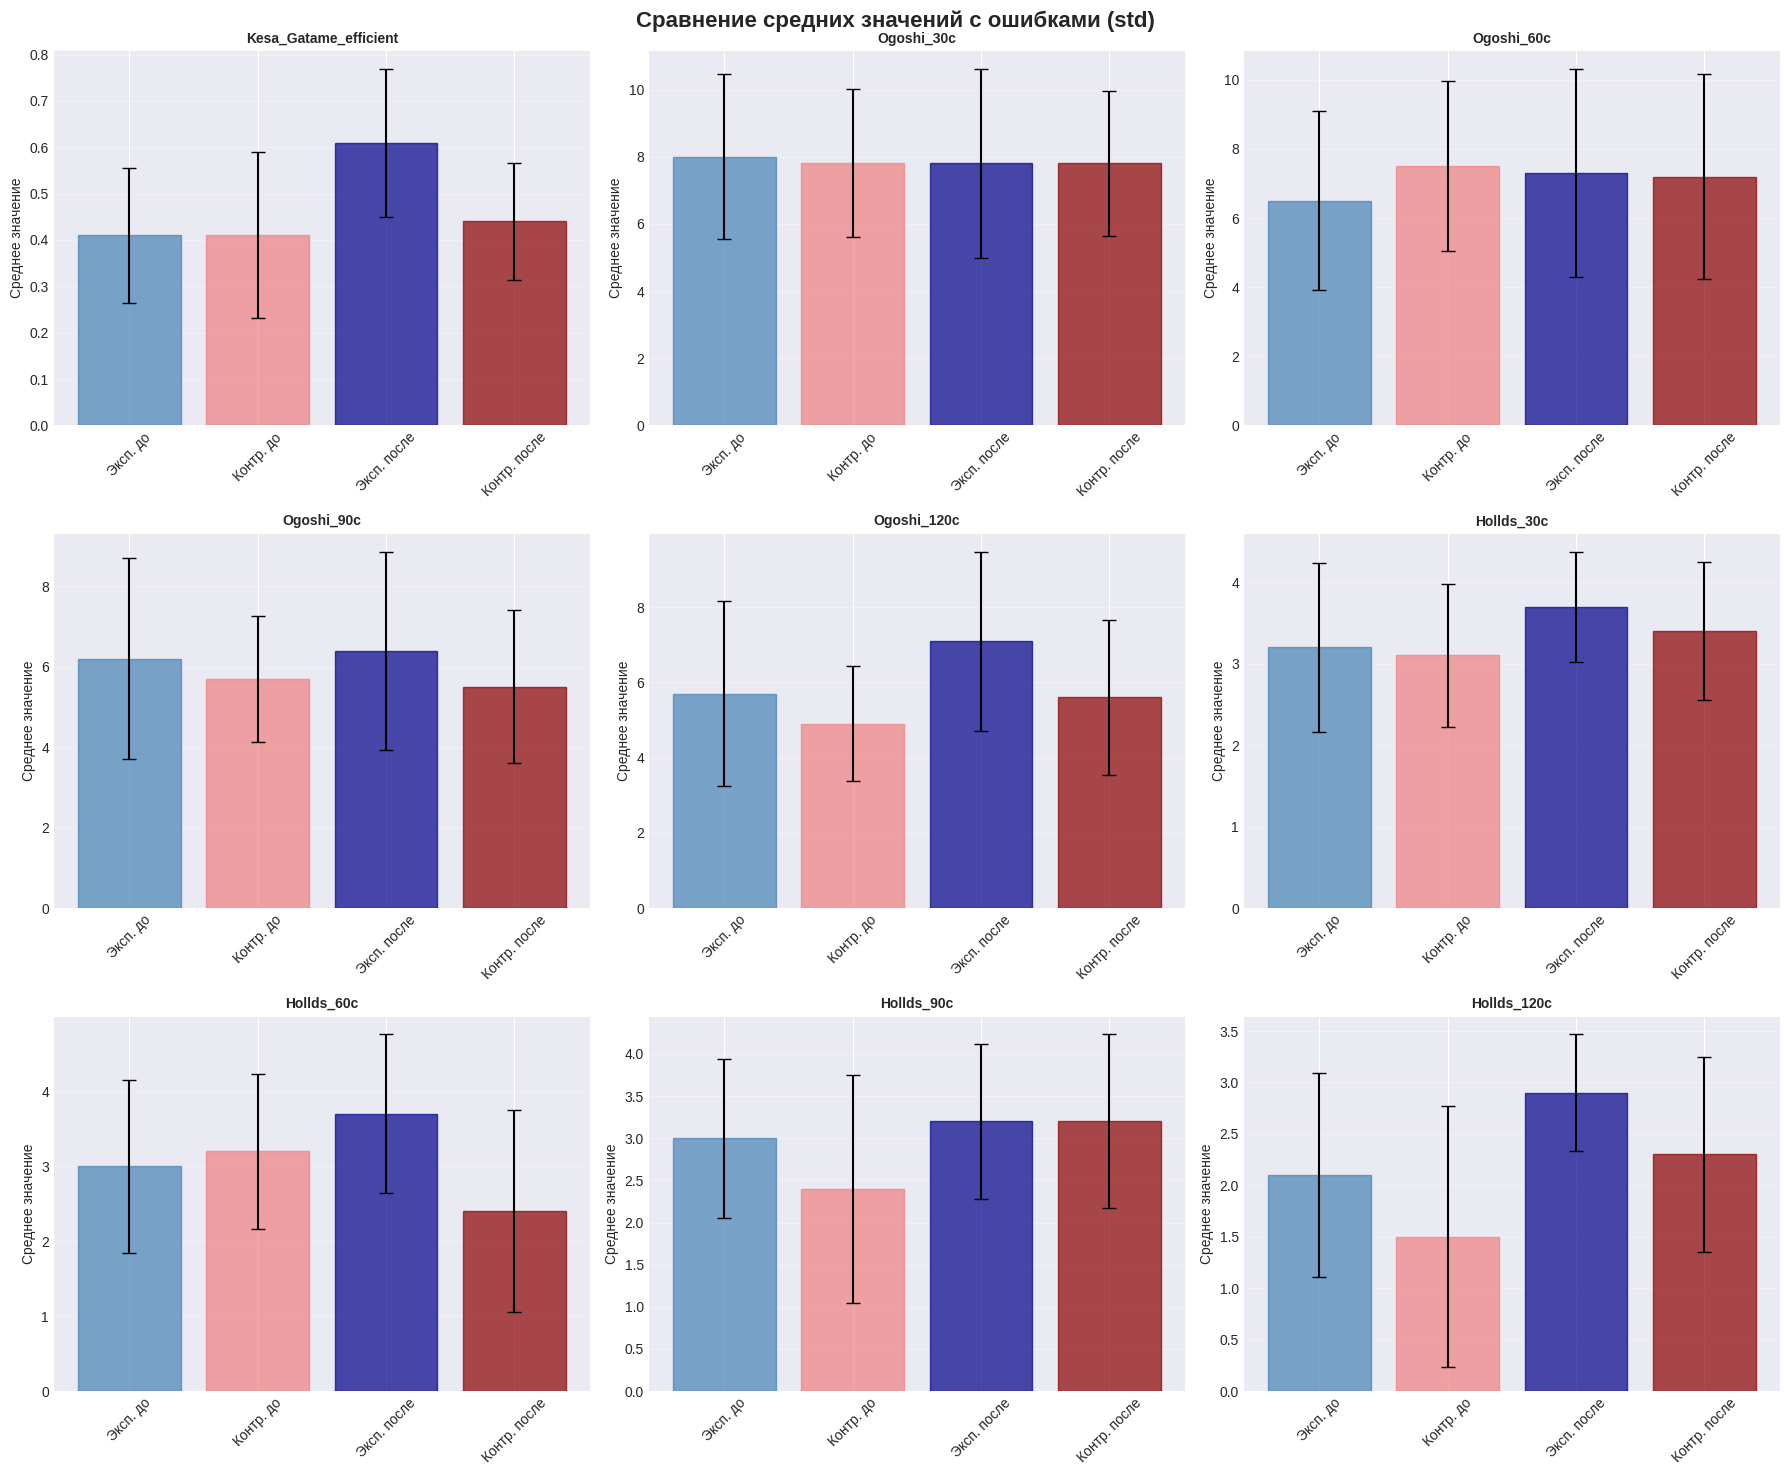


МАТЕМАТИЧЕСКАЯ МОДЕЛЬ ИЗМЕНЕНИЙ

Модель предсказания эффективности Kesa_Gatame после эксперимента:
R² = 1.0000
Коэффициенты: [ 1.74176776  0.16799538 -0.01062969 -0.3270364   0.11380705 -0.05141537
  0.03235124  0.16348931  0.05707683]
Интерсепт: -0.5429


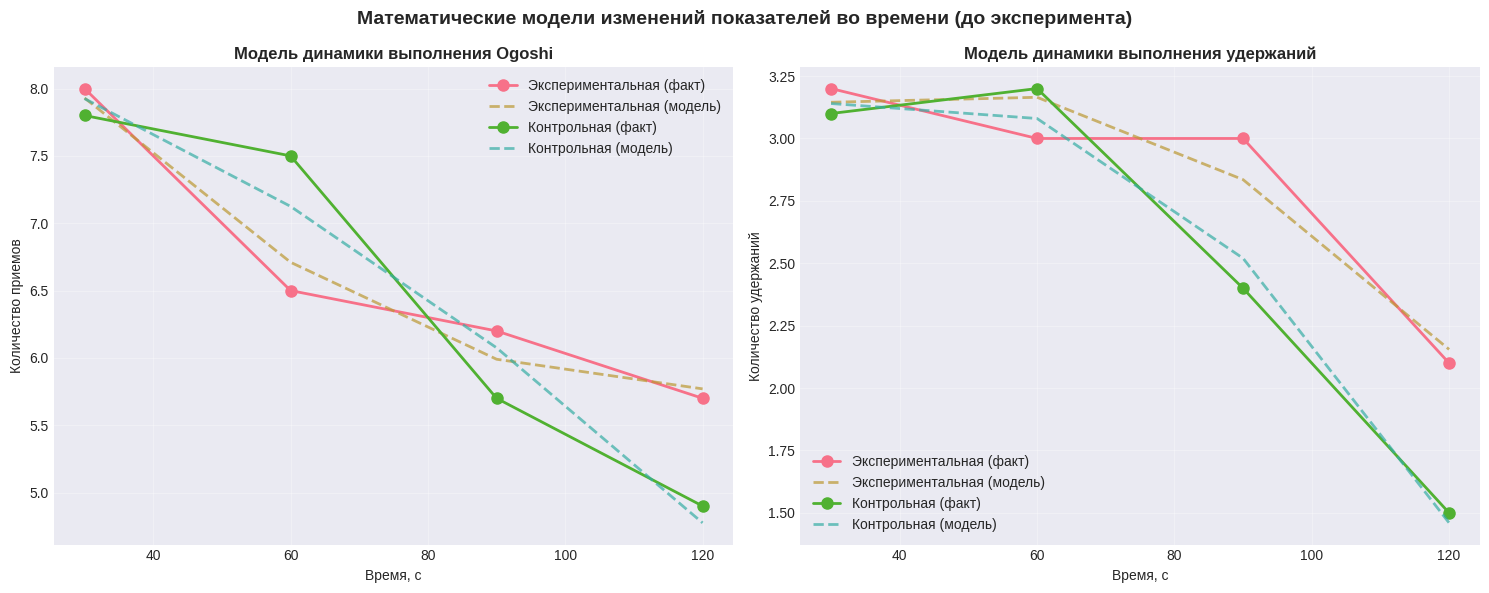


5 ИДЕЙ ДЛЯ ДАЛЬНЕЙШЕГО ИССЛЕДОВАНИЯ ДАННЫХ

1. АНАЛИЗ ВЫНОСЛИВОСТИ (скорость снижения эффективности)
   - Расчет коэффициента утомляемости
   - Сравнение темпов снижения производительности между группами


Коэффициенты утомляемости для Ogoshi (отрицательные значения указывают на снижение):

ДО ЭКСПЕРИМЕНТА:
Контрольная: -0.0350
Экспериментальная: -0.0240

ПОСЛЕ ЭКСПЕРИМЕНТА:
Контрольная: -0.0277
Экспериментальная: -0.0100

2. КЛАСТЕРНЫЙ АНАЛИЗ СПОРТСМЕНОВ
   - Группировка спортсменов по паттернам изменений
   - Выявление типов реагирования на тренировочную программу



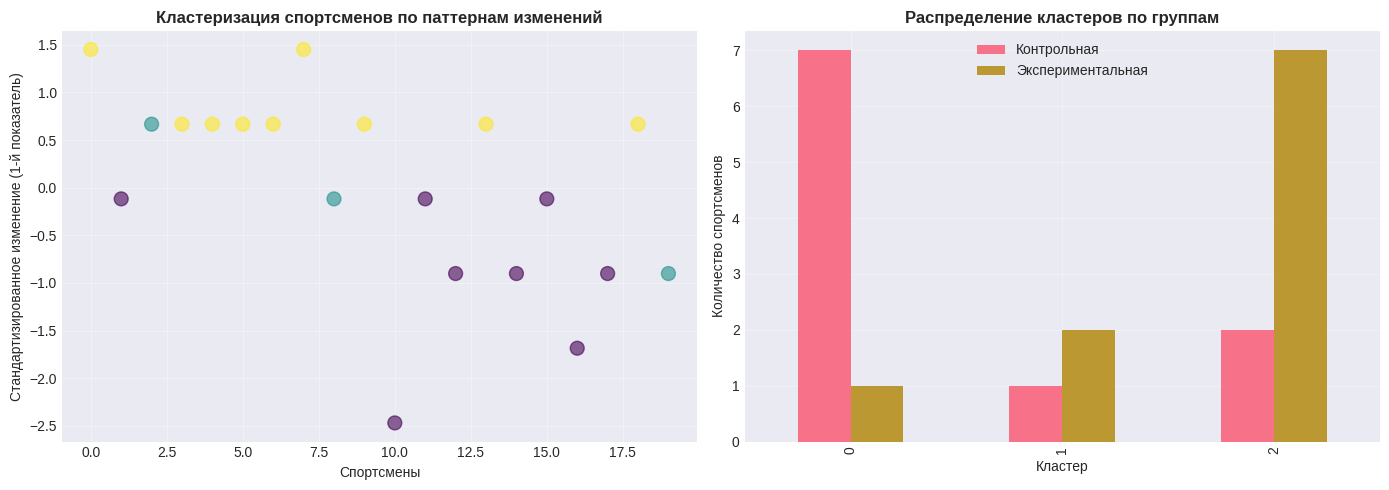


3. АНАЛИЗ ВЗАИМОСВЯЗИ ТЕХНИЧЕСКИХ ДЕЙСТВИЙ
   - Корреляционный анализ между различными приемами
   - Построение сетевой модели взаимовлияний



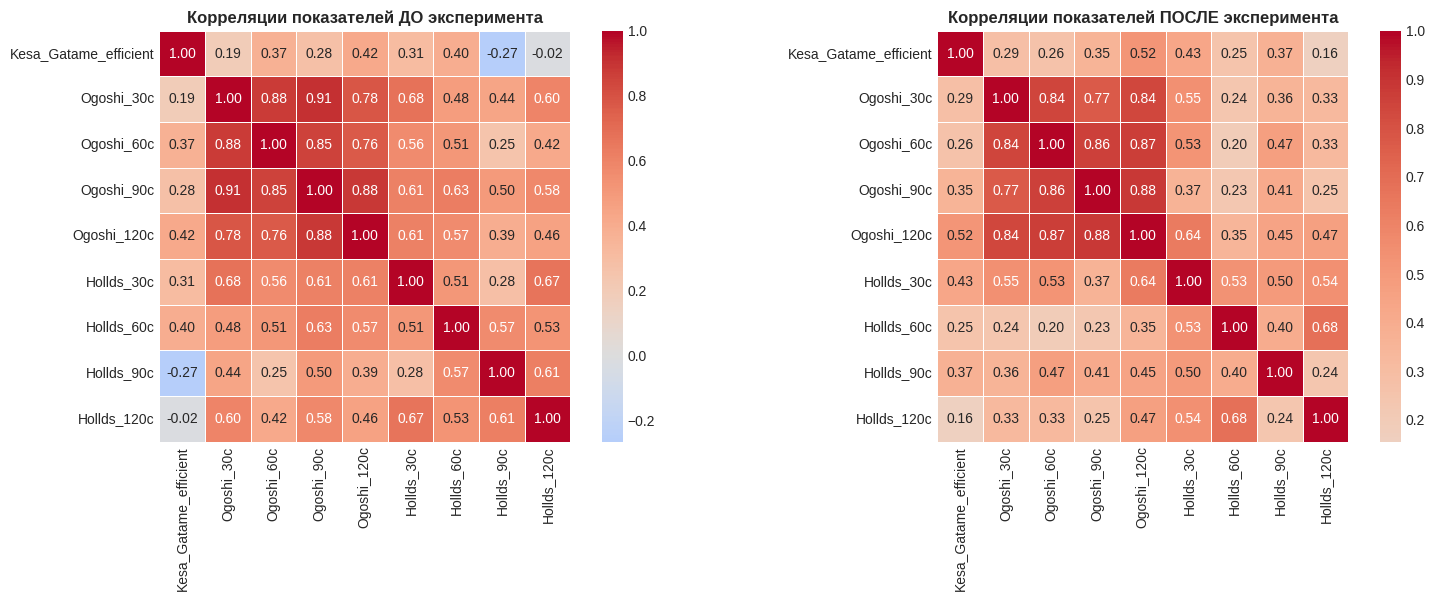


4. ПРОГНОЗИРОВАНИЕ ЭФФЕКТИВНОСТИ
   - Построение моделей машинного обучения для предсказания результатов
   - Определение ключевых факторов успеха


Важность показателей для прогнозирования эффективности Kesa_Gatame:
                 feature  importance
0  Kesa_Gatame_efficient    0.344592
2             Ogoshi_60с    0.144000
1             Ogoshi_30с    0.136855
4            Ogoshi_120с    0.100059
3             Ogoshi_90с    0.068731
8            Hollds_120с    0.067087
7             Hollds_90с    0.050185
5             Hollds_30с    0.048617
6             Hollds_60с    0.039874


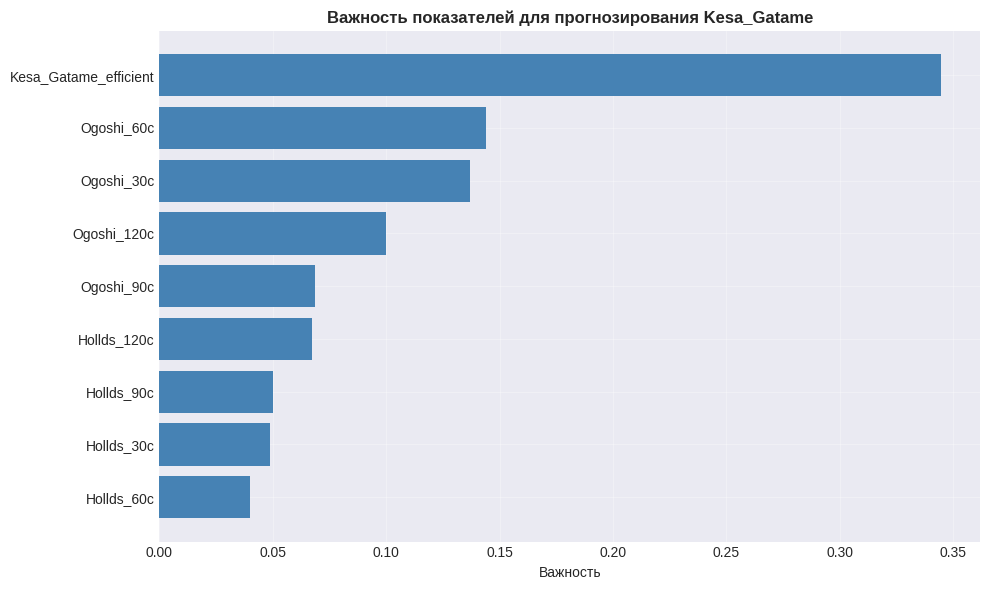


5. АНАЛИЗ ИНДИВИДУАЛЬНЫХ ТРАЕКТОРИЙ РАЗВИТИЯ
   - Персонализированный анализ прогресса каждого спортсмена
   - Выявление факторов, влияющих на индивидуальный прогресс



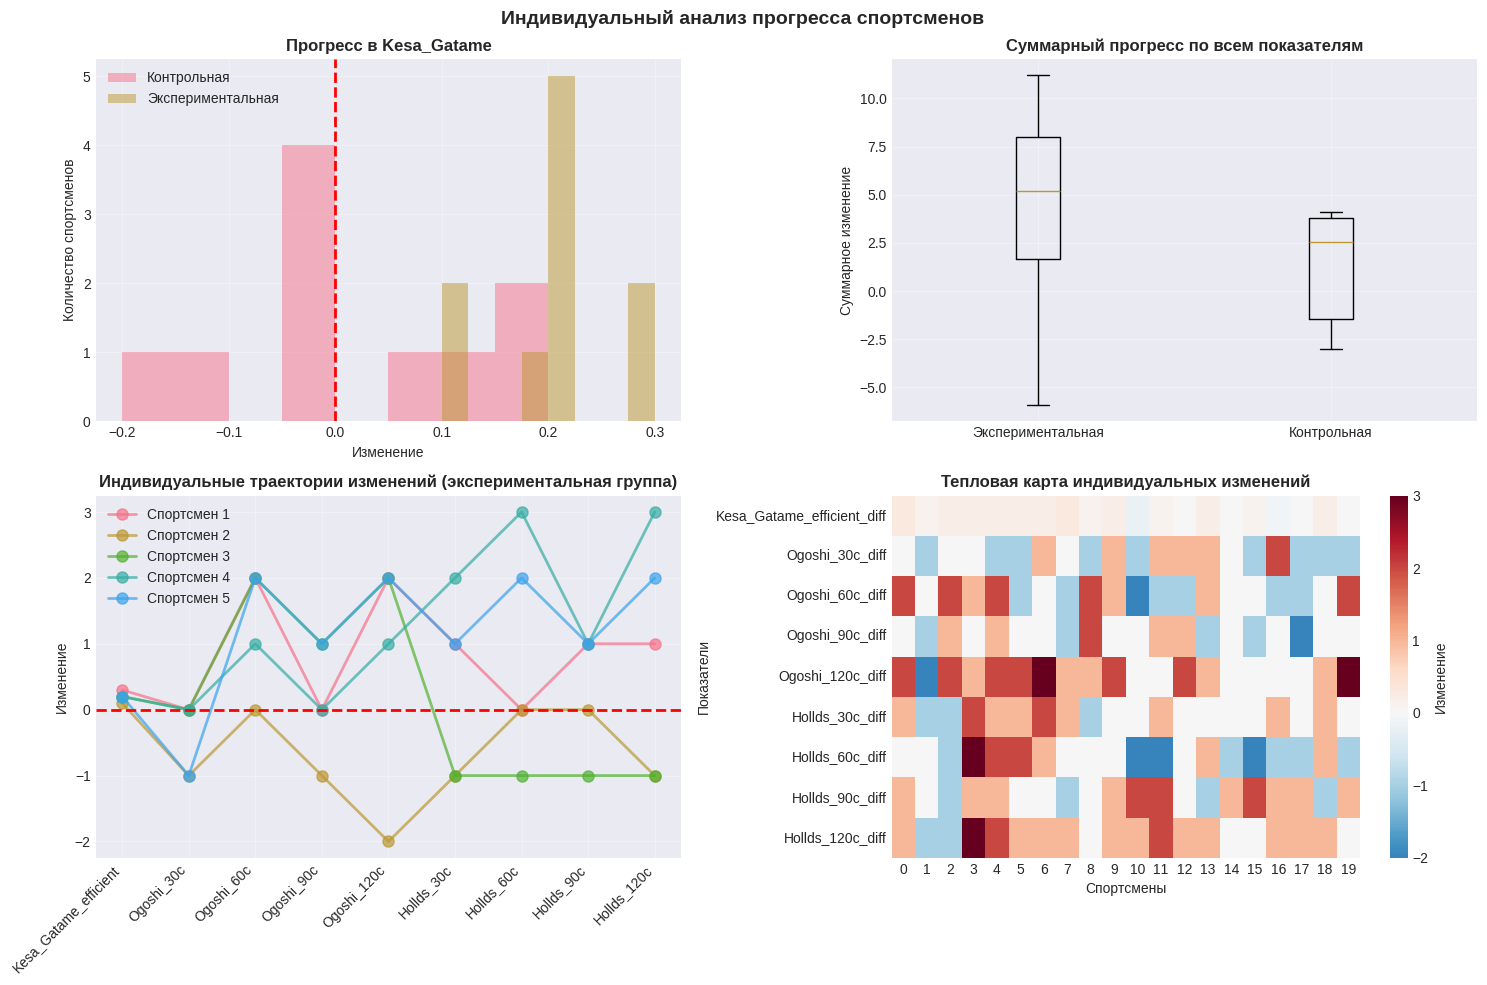


ИТОГОВЫЕ ВЫВОДЫ

Количество показателей со значимыми различиями в изменениях: 2

Значимые различия обнаружены для:
                variable   p_value
0  Kesa_Gatame_efficient  0.001339
6             Hollds_60с  0.011660

Средний суммарный прогресс:
Экспериментальная группа: 4.60
Контрольная группа: 1.33
Разница: 3.27

Эффективность эксперимента (разница в прогрессе): 3.27

ЗАВЕРШЕНО


In [ ]:
#!pip install pingouin openpyxl plotly

# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene, mannwhitneyu, ttest_ind, f_oneway
import pingouin as pg
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Загрузка данных
print("Загрузка данных...")
from google.colab import files
uploaded = files.upload()

# Чтение данных
file_name = list(uploaded.keys())[0]
df_before = pd.read_excel(file_name, sheet_name='before')
df_after = pd.read_excel(file_name, sheet_name='after')

# Просмотр названий столбцов для проверки
print("\nНазвания столбцов в данных до эксперимента:")
print(df_before.columns.tolist())
print("\nНазвания столбцов в данных после эксперимента:")
print(df_after.columns.tolist())

# Правильные названия столбцов (как в ваших данных)
variables = ['Kesa_Gatame_efficient', 'Ogoshi_30с', 'Ogoshi_60с',
             'Ogoshi_90с', 'Ogoshi_120с', 'Hollds_30с', 'Hollds_60с',
             'Hollds_90с', 'Hollds_120с']

print("\n" + "="*80)
print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА")
print("="*80)

def descriptive_stats(df, period):
    print(f"\n{period}:")
    print(f"Экспериментальная группа (Groupe=1): n={len(df[df['Groupe']==1])}")
    print(f"Контрольная группа (Groupe=0): n={len(df[df['Groupe']==0])}")

    stats_df = df.groupby('Groupe')[variables].agg(['mean', 'std', 'min', 'max']).round(2)
    print(stats_df)

descriptive_stats(df_before, "ДО ЭКСПЕРИМЕНТА")
descriptive_stats(df_after, "ПОСЛЕ ЭКСПЕРИМЕНТА")

# 1. СТАТИСТИЧЕСКАЯ ПРОВЕРКА НОРМАЛЬНОСТИ
print("\n" + "="*80)
print("ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ (тест Шапиро-Уилка)")
print("="*80)

def check_normality(df, variables, period):
    print(f"\n{period}:")
    for var in variables:
        stat, p_value = shapiro(df[var].dropna())
        normal = "нормальное" if p_value > 0.05 else "НЕ нормальное"
        print(f"{var}: p-value = {p_value:.4f} - {normal} распределение")

check_normality(df_before, variables, "ДО ЭКСПЕРИМЕНТА")
check_normality(df_after, variables, "ПОСЛЕ ЭКСПЕРИМЕНТА")

# 2. СРАВНЕНИЕ ГРУПП ДО ЭКСПЕРИМЕНТА
print("\n" + "="*80)
print("СРАВНЕНИЕ КОНТРОЛЬНОЙ И ЭКСПЕРИМЕНТАЛЬНОЙ ГРУПП ДО ЭКСПЕРИМЕНТА")
print("="*80)

def compare_groups(df, variables):
    results = []
    for var in variables:
        group1 = df[df['Groupe']==1][var].dropna()
        group0 = df[df['Groupe']==0][var].dropna()

        # Проверка равенства дисперсий
        stat_levene, p_levene = levene(group1, group0)

        # Выбор теста
        if p_levene > 0.05:
            stat, p_value = ttest_ind(group1, group0, equal_var=True)
            test_name = "t-test"
        else:
            stat, p_value = mannwhitneyu(group1, group0)
            test_name = "Mann-Whitney U"

        results.append({
            'variable': var,
            'test': test_name,
            'levene_p': p_levene,
            'p_value': p_value,
            'significant': 'Да' if p_value < 0.05 else 'Нет'
        })

    return pd.DataFrame(results)

comparison_before = compare_groups(df_before, variables)
print("\nДО ЭКСПЕРИМЕНТА:")
print(comparison_before.to_string())

# 3. СРАВНЕНИЕ ГРУПП ПОСЛЕ ЭКСПЕРИМЕНТА
comparison_after = compare_groups(df_after, variables)
print("\nПОСЛЕ ЭКСПЕРИМЕНТА:")
print(comparison_after.to_string())

# 4. АНАЛИЗ ИЗМЕНЕНИЙ (разница "после - до")
print("\n" + "="*80)
print("АНАЛИЗ ИЗМЕНЕНИЙ ПОКАЗАТЕЛЕЙ")
print("="*80)

# Создание датафреймов с разницей
df_diff = pd.DataFrame()
df_diff['Groupe'] = df_before['Groupe']

for var in variables:
    df_diff[f'{var}_diff'] = df_after[var] - df_before[var]

# Сравнение изменений между группами
diff_comparison = compare_groups(df_diff, [f'{var}_diff' for var in variables])
diff_comparison['variable'] = diff_comparison['variable'].str.replace('_diff', '')
print("\nСравнение изменений между группами:")
print(diff_comparison.to_string())

# 5. ВИЗУАЛИЗАЦИИ
print("\n" + "="*80)
print("СОЗДАНИЕ ВИЗУАЛИЗАЦИЙ")
print("="*80)

# 5.1 Boxplot сравнения групп до и после
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for idx, var in enumerate(variables):
    data_to_plot = []
    labels = []

    # Экспериментальная группа до
    exp_before = df_before[df_before['Groupe']==1][var].values
    # Контрольная группа до
    con_before = df_before[df_before['Groupe']==0][var].values
    # Экспериментальная группа после
    exp_after = df_after[df_after['Groupe']==1][var].values
    # Контрольная группа после
    con_after = df_after[df_after['Groupe']==0][var].values

    data_to_plot.extend([exp_before, con_before, exp_after, con_after])
    labels.extend(['Эксп. до', 'Контр. до', 'Эксп. после', 'Контр. после'])

    bp = axes[idx].boxplot(data_to_plot, labels=labels, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightcoral')
    bp['boxes'][2].set_facecolor('steelblue')
    bp['boxes'][3].set_facecolor('indianred')

    axes[idx].set_title(f'{var}', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Значение')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Сравнение показателей между группами до и после эксперимента',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 5.2 Тепловая карта корреляций изменений
plt.figure(figsize=(12, 10))
diff_vars = [f'{var}_diff' for var in variables]
corr_matrix = df_diff[diff_vars].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Корреляционная матрица изменений показателей', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 5.3 График изменений для каждого показателя
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for idx, var in enumerate(variables):
    exp_changes = df_diff[df_diff['Groupe']==1][f'{var}_diff']
    con_changes = df_diff[df_diff['Groupe']==0][f'{var}_diff']

    axes[idx].hist(exp_changes, alpha=0.5, label='Экспериментальная группа', bins=8, color='blue')
    axes[idx].hist(con_changes, alpha=0.5, label='Контрольная группа', bins=8, color='red')
    axes[idx].axvline(x=0, color='red', linestyle='--', alpha=0.7)
    axes[idx].set_title(f'{var} - изменения', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Изменение')
    axes[idx].set_ylabel('Частота')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Распределение изменений показателей по группам',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 5.4 Столбчатая диаграмма средних значений
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for idx, var in enumerate(variables):
    means = [
        df_before[df_before['Groupe']==1][var].mean(),
        df_before[df_before['Groupe']==0][var].mean(),
        df_after[df_after['Groupe']==1][var].mean(),
        df_after[df_after['Groupe']==0][var].mean()
    ]
    stds = [
        df_before[df_before['Groupe']==1][var].std(),
        df_before[df_before['Groupe']==0][var].std(),
        df_after[df_after['Groupe']==1][var].std(),
        df_after[df_after['Groupe']==0][var].std()
    ]

    x_pos = np.arange(4)
    bars = axes[idx].bar(x_pos, means, yerr=stds, capsize=5, alpha=0.7)
    bars[0].set_color('steelblue')
    bars[1].set_color('lightcoral')
    bars[2].set_color('darkblue')
    bars[3].set_color('darkred')

    axes[idx].set_xticks(x_pos)
    axes[idx].set_xticklabels(['Эксп. до', 'Контр. до', 'Эксп. после', 'Контр. после'], rotation=45)
    axes[idx].set_title(f'{var}', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Среднее значение')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.suptitle('Сравнение средних значений с ошибками (std)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. МАТЕМАТИЧЕСКАЯ МОДЕЛЬ ИЗМЕНЕНИЙ
print("\n" + "="*80)
print("МАТЕМАТИЧЕСКАЯ МОДЕЛЬ ИЗМЕНЕНИЙ")
print("="*80)

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# Создание модели для экспериментальной группы
exp_before = df_before[df_before['Groupe']==1]
exp_after = df_after[df_after['Groupe']==1]

# Модель множественной линейной регрессии
X = exp_before[variables].values
y = exp_after['Kesa_Gatame_efficient'].values

model = LinearRegression()
model.fit(X, y)

print("\nМодель предсказания эффективности Kesa_Gatame после эксперимента:")
print(f"R² = {model.score(X, y):.4f}")
print(f"Коэффициенты: {model.coef_}")
print(f"Интерсепт: {model.intercept_:.4f}")

# Создание модели изменений во времени
time_points = [30, 60, 90, 120]
time_series_ogoshi = []
time_series_holds = []

for group_name, group_data in [('Экспериментальная', exp_before),
                                ('Контрольная', df_before[df_before['Groupe']==0])]:
    ogoshi_means = [group_data[f'Ogoshi_{t}с'].mean() for t in time_points]
    holds_means = [group_data[f'Hollds_{t}с'].mean() for t in time_points]
    time_series_ogoshi.append(ogoshi_means)
    time_series_holds.append(holds_means)

# Полиномиальная регрессия для моделирования утомления
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(np.array(time_points).reshape(-1, 1))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for idx, (ogoshi_data, holds_data, label) in enumerate(zip(time_series_ogoshi, time_series_holds,
                                                           ['Экспериментальная', 'Контрольная'])):
    # Модель для Ogoshi
    model_ogoshi = LinearRegression()
    model_ogoshi.fit(X_poly, ogoshi_data)
    y_pred_ogoshi = model_ogoshi.predict(X_poly)

    # Модель для Hollds
    model_holds = LinearRegression()
    model_holds.fit(X_poly, holds_data)
    y_pred_holds = model_holds.predict(X_poly)

    axes[0].plot(time_points, ogoshi_data, 'o-', label=f'{label} (факт)', linewidth=2, markersize=8)
    axes[0].plot(time_points, y_pred_ogoshi, '--', label=f'{label} (модель)', alpha=0.7, linewidth=2)
    axes[1].plot(time_points, holds_data, 'o-', label=f'{label} (факт)', linewidth=2, markersize=8)
    axes[1].plot(time_points, y_pred_holds, '--', label=f'{label} (модель)', alpha=0.7, linewidth=2)

axes[0].set_title('Модель динамики выполнения Ogoshi', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Время, с')
axes[0].set_ylabel('Количество приемов')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Модель динамики выполнения удержаний', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Время, с')
axes[1].set_ylabel('Количество удержаний')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Математические модели изменений показателей во времени (до эксперимента)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 7. ПЯТЬ ИДЕЙ ДЛЯ ДАЛЬНЕЙШЕГО ИССЛЕДОВАНИЯ
print("\n" + "="*80)
print("5 ИДЕЙ ДЛЯ ДАЛЬНЕЙШЕГО ИССЛЕДОВАНИЯ ДАННЫХ")
print("="*80)

print("""
1. АНАЛИЗ ВЫНОСЛИВОСТИ (скорость снижения эффективности)
   - Расчет коэффициента утомляемости
   - Сравнение темпов снижения производительности между группами
""")

# Пример реализации идеи 1
fatigue_rate_ogoshi_before = {}
fatigue_rate_ogoshi_after = {}

for group in [0, 1]:
    group_name = 'Экспериментальная' if group == 1 else 'Контрольная'

    # До эксперимента
    group_data_before = df_before[df_before['Groupe']==group]
    ogoshi_series_before = [group_data_before[f'Ogoshi_{t}с'].mean() for t in time_points]
    slope_before, intercept_before = np.polyfit(time_points, ogoshi_series_before, 1)
    fatigue_rate_ogoshi_before[group_name] = slope_before

    # После эксперимента
    group_data_after = df_after[df_after['Groupe']==group]
    ogoshi_series_after = [group_data_after[f'Ogoshi_{t}с'].mean() for t in time_points]
    slope_after, intercept_after = np.polyfit(time_points, ogoshi_series_after, 1)
    fatigue_rate_ogoshi_after[group_name] = slope_after

print("\nКоэффициенты утомляемости для Ogoshi (отрицательные значения указывают на снижение):")
print("\nДО ЭКСПЕРИМЕНТА:")
for group, rate in fatigue_rate_ogoshi_before.items():
    print(f"{group}: {rate:.4f}")
print("\nПОСЛЕ ЭКСПЕРИМЕНТА:")
for group, rate in fatigue_rate_ogoshi_after.items():
    print(f"{group}: {rate:.4f}")

print("""
2. КЛАСТЕРНЫЙ АНАЛИЗ СПОРТСМЕНОВ
   - Группировка спортсменов по паттернам изменений
   - Выявление типов реагирования на тренировочную программу
""")

# Пример реализации идеи 2
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Подготовка данных для кластеризации (изменения показателей)
scaler = StandardScaler()
features_for_clustering = [f'{var}_diff' for var in variables]
X_cluster = scaler.fit_transform(df_diff[features_for_clustering])

# Кластеризация
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster)

# Визуализация кластеров
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График распределения кластеров
axes[0].scatter(range(len(clusters)), X_cluster[:, 0], c=clusters, cmap='viridis', alpha=0.6, s=100)
axes[0].set_title('Кластеризация спортсменов по паттернам изменений', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Спортсмены')
axes[0].set_ylabel('Стандартизированное изменение (1-й показатель)')
axes[0].grid(True, alpha=0.3)

# Распределение кластеров по группам
cluster_df = pd.DataFrame({'cluster': clusters, 'group': df_diff['Groupe']})
cluster_counts = pd.crosstab(cluster_df['cluster'], cluster_df['group'])
cluster_counts.columns = ['Контрольная', 'Экспериментальная']
cluster_counts.plot(kind='bar', ax=axes[1])
axes[1].set_title('Распределение кластеров по группам', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Кластер')
axes[1].set_ylabel('Количество спортсменов')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("""
3. АНАЛИЗ ВЗАИМОСВЯЗИ ТЕХНИЧЕСКИХ ДЕЙСТВИЙ
   - Корреляционный анализ между различными приемами
   - Построение сетевой модели взаимовлияний
""")

# Пример реализации идеи 3
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Корреляционная матрица до эксперимента
corr_before = df_before[variables].corr()
sns.heatmap(corr_before, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=axes[0])
axes[0].set_title('Корреляции показателей ДО эксперимента', fontsize=12, fontweight='bold')

# Корреляционная матрица после эксперимента
corr_after = df_after[variables].corr()
sns.heatmap(corr_after, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=axes[1])
axes[1].set_title('Корреляции показателей ПОСЛЕ эксперимента', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("""
4. ПРОГНОЗИРОВАНИЕ ЭФФЕКТИВНОСТИ
   - Построение моделей машинного обучения для предсказания результатов
   - Определение ключевых факторов успеха
""")

# Пример реализации идеи 4
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Подготовка данных
X = df_before[variables].values
y = df_after['Kesa_Gatame_efficient'].values

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучение модели Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Оценка важности признаков
feature_importance = pd.DataFrame({
    'feature': variables,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nВажность показателей для прогнозирования эффективности Kesa_Gatame:")
print(feature_importance)

# Визуализация важности признаков
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
plt.xlabel('Важность')
plt.title('Важность показателей для прогнозирования Kesa_Gatame', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("""
5. АНАЛИЗ ИНДИВИДУАЛЬНЫХ ТРАЕКТОРИЙ РАЗВИТИЯ
   - Персонализированный анализ прогресса каждого спортсмена
   - Выявление факторов, влияющих на индивидуальный прогресс
""")

# Пример реализации идеи 5
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Прогресс по Kesa_Gatame
for group in [0, 1]:
    group_mask = df_before['Groupe'] == group
    progress = df_after[group_mask]['Kesa_Gatame_efficient'].values - df_before[group_mask]['Kesa_Gatame_efficient'].values
    axes[0, 0].hist(progress, alpha=0.5, label=f"{'Экспериментальная' if group==1 else 'Контрольная'}", bins=8)
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_title('Прогресс в Kesa_Gatame', fontweight='bold')
axes[0, 0].set_xlabel('Изменение')
axes[0, 0].set_ylabel('Количество спортсменов')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Суммарный прогресс по всем показателям
total_progress_exp = df_diff[df_diff['Groupe']==1][[f'{var}_diff' for var in variables]].sum(axis=1)
total_progress_con = df_diff[df_diff['Groupe']==0][[f'{var}_diff' for var in variables]].sum(axis=1)

axes[0, 1].boxplot([total_progress_exp, total_progress_con],
                   labels=['Экспериментальная', 'Контрольная'])
axes[0, 1].set_title('Суммарный прогресс по всем показателям', fontweight='bold')
axes[0, 1].set_ylabel('Суммарное изменение')
axes[0, 1].grid(True, alpha=0.3)

# Индивидуальные траектории (первые 5 спортсменов из экспериментальной группы)
exp_indices = df_diff[df_diff['Groupe']==1].index[:5]
for i, idx in enumerate(exp_indices):
    exp_changes = df_diff.iloc[idx][[f'{var}_diff' for var in variables]].values
    axes[1, 0].plot(range(len(variables)), exp_changes, 'o-', alpha=0.7, label=f'Спортсмен {i+1}', linewidth=2, markersize=8)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_title('Индивидуальные траектории изменений (экспериментальная группа)', fontweight='bold')
axes[1, 0].set_xticks(range(len(variables)))
axes[1, 0].set_xticklabels([v.replace('_diff', '') for v in [f'{var}_diff' for var in variables]], rotation=45, ha='right')
axes[1, 0].set_ylabel('Изменение')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Тепловая карта индивидуальных изменений
individual_changes = df_diff[[f'{var}_diff' for var in variables]].T
sns.heatmap(individual_changes, cmap='RdBu_r', center=0, ax=axes[1, 1],
            cbar_kws={'label': 'Изменение'})
axes[1, 1].set_title('Тепловая карта индивидуальных изменений', fontweight='bold')
axes[1, 1].set_xlabel('Спортсмены')
axes[1, 1].set_ylabel('Показатели')

plt.suptitle('Индивидуальный анализ прогресса спортсменов', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Финальная статистика
print("\n" + "="*80)
print("ИТОГОВЫЕ ВЫВОДЫ")
print("="*80)

# Подсчет значимых различий
significant_changes = diff_comparison[diff_comparison['significant'] == 'Да']
print(f"\nКоличество показателей со значимыми различиями в изменениях: {len(significant_changes)}")
if len(significant_changes) > 0:
    print("\nЗначимые различия обнаружены для:")
    print(significant_changes[['variable', 'p_value']].to_string())

# Средний прогресс по группам
mean_progress_exp = total_progress_exp.mean()
mean_progress_con = total_progress_con.mean()
print(f"\nСредний суммарный прогресс:")
print(f"Экспериментальная группа: {mean_progress_exp:.2f}")
print(f"Контрольная группа: {mean_progress_con:.2f}")
print(f"Разница: {mean_progress_exp - mean_progress_con:.2f}")

# Эффективность эксперимента
print(f"\nЭффективность эксперимента (разница в прогрессе): {mean_progress_exp - mean_progress_con:.2f}")

print("\n" + "="*80)
print("ЗАВЕРШЕНО")
print("="*80)